#**COMP0036: Beat the Bookie**

By Yeow Keng Ng

## Import Libraries

In [1]:
!pip install xgboost

from google.colab import drive

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    log_loss,
    confusion_matrix,
    classification_report
)
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.8/296.8 MB 1.2 MB/s eta 0:00:00


## Load and Clean Data

This section focuses on loading the raw dataset and performing initial cleaning steps.

The key operations include:
1. Mounting Google Drive to access data files.
2. Loading the "epl-training.csv" dataset into a pandas DataFrame.
3. Creating a copy of the training data (`train_df`) for manipulation.
4. Removing rows with any missing values (`dropna()`) to ensure data integrity for subsequent steps.
5. Standardizing team names (e.g., Nott'm Forest to Nottingham Forest) for consistency.
6. Converting the `Date` column to datetime objects and sorting the data chronologically.
7. Identifying and removing duplicate match entries (based on `Date`, `HomeTeam`, `AwayTeam`) to prevent data redundancy issues.
8. Encoding categorical team names into numerical labels using `LabelEncoder`.
9. Encoding the target variable `FTR` into numerical values using mapping.
10. Deriving a `Season` column from the `Date` to group matches by football seasons.
11. The columns in the `train_df` are reordered for convenient feature engineering.
12. Similarly, the "epl-test.csv" dataset was loaded into a pandas DataFrame, and a copy of the test data (`test_df`) was created with the `Date` column converted to datetime objects.

Feature Definitions (from "epl-training.csv")

- **Date** — The date that the match took place  
- **HomeTeam** — The team playing at home  
- **AwayTeam** — The team playing away  
- **FTHG** — Goals scored by the home team at full time  
- **FTAG** — Goals scored by the away team at full time  
- **FTR** — Full-time result *(target variable: H = home win, D = draw, A = away win)*  
- **HTHG** — Goals scored by the home team at half time  
- **HTAG** — Goals scored by the away team at half time  
- **HTR** — Half-time result  
- **Referee** — Name of the referee officiating the match  
- **HS** — Total number of shots by the home team  
- **AS** — Total number of shots by the away team  
- **HST** — Total number of shots on target by the home team  
- **AST** — Total number of shots on target by the away team  
- **HF** — Total number of fouls committed by the home team  
- **AF** — Total number of fouls committed by the away team  
- **HC** — Total number of corners by the home team  
- **AC** — Total number of corners by the away team  
- **HY** — Total number of yellow cards received by the home team  
- **AY** — Total number of yellow cards received by the away team  
- **HR** — Total number of red cards received by the home team  
- **AR** — Total number of red cards received by the away team  

In [2]:
drive.mount("/content/drive", force_remount=False)

Mounted at /content/drive


In [3]:
"""
# Download Season 25/26 Premier League from https://www.football-data.co.uk/englandm.php
"""

# Load training data
datapath = "/content/drive/MyDrive/COMP0036/Coursework/Data_Files/"
epl_train = pd.read_csv(datapath + "epl-training.csv")
epl_train_extra = pd.read_csv(datapath + "E0.csv")

# Remove extra data from the secpnd dataset to match the first
# Keep only columns up to AR (AR included)
def keep_until_AR(df):
    cols = list(df.columns)
    idx = cols.index("AR")
    return df.iloc[:, :idx+1]
epl_train_extra = keep_until_AR(epl_train_extra)

# Drop division and time
cols_to_drop = [c for c in ["Div", "Time"] if c in epl_train_extra.columns]
epl_train_extra = epl_train_extra.drop(columns=cols_to_drop, errors="ignore")

# Concatenate
train_df = pd.concat([epl_train, epl_train_extra], ignore_index=True)

# Remove rows with missing values
train_df = train_df.dropna().reset_index(drop=True)

# Check columns after cleaning
train_df.columns

Index(['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG',
       'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HF', 'AF',
       'HY', 'AY', 'HR', 'AR'],
      dtype='object')

In [4]:
# Map for team name corrections
team_name_mapping = {
    "Nott'm Forest": "Nottingham Forest"
}

# Replace team names in "HomeTeam" and "AwayTeam" columns
train_df["HomeTeam"] = train_df["HomeTeam"].replace(team_name_mapping)
train_df["AwayTeam"] = train_df["AwayTeam"].replace(team_name_mapping)

In [5]:
# Convert "Date" to datetime, sort by date and reset index
train_df["Date"] = pd.to_datetime(train_df["Date"], dayfirst=True)
train_df = train_df.sort_values(by="Date").reset_index(drop=True)

In [6]:
# Find rows where (Date, HomeTeam, AwayTeam) is duplicated
train_df.duplicated(
    subset=["Date", "HomeTeam", "AwayTeam"], keep=False
    ).sum()   # keep=False marks every single instance of a duplicate row as True

np.int64(200)

In [7]:
# Find rows where (Date, HomeTeam, AwayTeam) is duplicated
dup_key = train_df.duplicated(subset=["Date", "HomeTeam", "AwayTeam", "FTR"], keep=False)

# All duplicated rows, sorted nicely
dup_matches = train_df[dup_key].sort_values(["Date", "HomeTeam", "AwayTeam", "FTR"])

# Sanity check
dup_matches

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,HST,AST,HC,AC,HF,AF,HY,AY,HR,AR
8740,2023-08-11,Burnley,Man City,0.0,3.0,A,0.0,2.0,A,C Pawson,...,1.0,8.0,6.0,5.0,11.0,8.0,0.0,0.0,1.0,0.0
8741,2023-08-11,Burnley,Man City,0.0,3.0,A,0.0,2.0,A,C Pawson,...,1.0,8.0,11.0,8.0,6.0,5.0,0.0,0.0,1.0,0.0
8746,2023-08-12,Arsenal,Nottingham Forest,2.0,1.0,H,2.0,0.0,H,M Oliver,...,7.0,2.0,8.0,3.0,12.0,12.0,2.0,2.0,0.0,0.0
8753,2023-08-12,Arsenal,Nottingham Forest,2.0,1.0,H,2.0,0.0,H,M Oliver,...,7.0,2.0,12.0,12.0,8.0,3.0,2.0,2.0,0.0,0.0
8750,2023-08-12,Bournemouth,West Ham,1.0,1.0,D,0.0,0.0,D,P Bankes,...,5.0,3.0,10.0,4.0,9.0,14.0,1.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8935,2023-10-29,Liverpool,Nottingham Forest,3.0,0.0,H,2.0,0.0,H,C Salisbury,...,8.0,1.0,8.0,3.0,9.0,13.0,2.0,3.0,0.0,0.0
8930,2023-10-29,Man United,Man City,0.0,3.0,A,0.0,1.0,A,P Tierney,...,3.0,10.0,7.0,12.0,9.0,4.0,4.0,1.0,0.0,0.0
8932,2023-10-29,Man United,Man City,0.0,3.0,A,0.0,1.0,A,P Tierney,...,3.0,10.0,9.0,4.0,7.0,12.0,4.0,1.0,0.0,0.0
8936,2023-10-29,West Ham,Everton,0.0,1.0,A,0.0,0.0,D,S Attwell,...,2.0,4.0,4.0,3.0,7.0,11.0,4.0,1.0,0.0,0.0


In [8]:
# Drop duplicates, selecting the first occurrence
train_df = train_df.drop_duplicates(subset=["Date", "HomeTeam", "AwayTeam"], keep="first").reset_index(drop=True)

In [9]:
# # Encode team names as integers
# le = LabelEncoder()
# all_teams = pd.concat([train_df["HomeTeam"], train_df["AwayTeam"]]).unique()
# le.fit(all_teams)
# train_df["HomeTeam_encoded"] = le.transform(train_df["HomeTeam"])
# train_df["AwayTeam_encoded"] = le.transform(train_df["AwayTeam"])

# # Create a mapping from team names to integer labels
# team_name_mapping = {team: idx for idx, team in enumerate(le.classes_)}

# # Sanity check
# team_name_mapping

In [10]:
# Encode the target variable (FTR)
# Mapping 'H': Home Win, 'D': Draw, 'A': Away Win to numerical values
ftr_mapping = {"H": 0, "D": 1, "A": 2}
train_df["FTR_encoded"] = train_df["FTR"].map(ftr_mapping)
train_df

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,AST,HC,AC,HF,AF,HY,AY,HR,AR,FTR_encoded
0,2000-08-19,Charlton,Man City,4.0,0.0,H,2.0,0.0,H,Rob Harris,...,4.0,6.0,6.0,13.0,12.0,1.0,2.0,0.0,0.0,0
1,2000-08-19,Chelsea,West Ham,4.0,2.0,H,1.0,0.0,H,Graham Barber,...,5.0,7.0,7.0,19.0,14.0,1.0,2.0,0.0,0.0,0
2,2000-08-19,Coventry,Middlesbrough,1.0,3.0,A,1.0,1.0,D,Barry Knight,...,9.0,8.0,4.0,15.0,21.0,5.0,3.0,1.0,0.0,2
3,2000-08-19,Derby,Southampton,2.0,2.0,D,1.0,2.0,A,Andy D'Urso,...,6.0,5.0,8.0,11.0,13.0,1.0,1.0,0.0,0.0,1
4,2000-08-19,Leeds,Everton,2.0,0.0,H,2.0,0.0,H,Dermot Gallagher,...,6.0,6.0,4.0,21.0,20.0,1.0,3.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9615,2025-11-22,Brighton,Brentford,2.0,1.0,H,0.0,1.0,A,C Kavanagh,...,4.0,7.0,4.0,10.0,9.0,4.0,2.0,0.0,0.0,0
9616,2025-11-22,Newcastle,Man City,2.0,1.0,H,0.0,0.0,D,S Barrott,...,4.0,5.0,9.0,13.0,8.0,1.0,3.0,0.0,0.0,0
9617,2025-11-23,Arsenal,Tottenham,4.0,1.0,H,2.0,0.0,H,M Oliver,...,2.0,4.0,1.0,11.0,15.0,1.0,3.0,0.0,0.0,0
9618,2025-11-23,Leeds,Aston Villa,1.0,2.0,A,1.0,0.0,H,R Jones,...,3.0,3.0,3.0,18.0,16.0,5.0,1.0,0.0,0.0,2


In [11]:
# Create season name function
def season_name(date: pd.Timestamp):
    """Get season name from date."""
    month = date.month
    year = date.year
    if month >= 8:
        return year
    else:
        return year - 1

# Add "Season" column to train data
train_df["Season"] = train_df["Date"].apply(season_name)

# Sanity check
train_df[["Date", "Season"]]

,Date,Season
0,2000-08-19,2000
1,2000-08-19,2000
2,2000-08-19,2000
3,2000-08-19,2000
4,2000-08-19,2000
...,...,...
9615,2025-11-22,2025
9616,2025-11-22,2025
9617,2025-11-23,2025
9618,2025-11-23,2025


In [12]:
# Check season value counts
train_df["Season"].value_counts().sort_index()

,count
Season,
2000,380
2001,380
2002,380
2003,380
2004,380
2005,380
2006,380
2007,380
2008,380


In [13]:
# Check final train_df
train_df = train_df[["Date", "Season", "HomeTeam", "AwayTeam", "FTR_encoded", "FTHG", "FTAG", "FTR", "HTHG", "HTAG",
       "HTR", "Referee", "HS", "AS", "HST", "AST", "HC", "AC", "HF", "AF",
       "HY", "AY", "HR", "AR"]]

train_df

,Date,Season,HomeTeam,AwayTeam,FTR_encoded,FTHG,FTAG,FTR,HTHG,HTAG,...,HST,AST,HC,AC,HF,AF,HY,AY,HR,AR
0,2000-08-19,2000,Charlton,Man City,0,4.0,0.0,H,2.0,0.0,...,14.0,4.0,6.0,6.0,13.0,12.0,1.0,2.0,0.0,0.0
1,2000-08-19,2000,Chelsea,West Ham,0,4.0,2.0,H,1.0,0.0,...,10.0,5.0,7.0,7.0,19.0,14.0,1.0,2.0,0.0,0.0
2,2000-08-19,2000,Coventry,Middlesbrough,2,1.0,3.0,A,1.0,1.0,...,3.0,9.0,8.0,4.0,15.0,21.0,5.0,3.0,1.0,0.0
3,2000-08-19,2000,Derby,Southampton,1,2.0,2.0,D,1.0,2.0,...,4.0,6.0,5.0,8.0,11.0,13.0,1.0,1.0,0.0,0.0
4,2000-08-19,2000,Leeds,Everton,0,2.0,0.0,H,2.0,0.0,...,8.0,6.0,6.0,4.0,21.0,20.0,1.0,3.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9615,2025-11-22,2025,Brighton,Brentford,0,2.0,1.0,H,0.0,1.0,...,5.0,4.0,7.0,4.0,10.0,9.0,4.0,2.0,0.0,0.0
9616,2025-11-22,2025,Newcastle,Man City,0,2.0,1.0,H,0.0,0.0,...,5.0,4.0,5.0,9.0,13.0,8.0,1.0,3.0,0.0,0.0
9617,2025-11-23,2025,Arsenal,Tottenham,0,4.0,1.0,H,2.0,0.0,...,8.0,2.0,4.0,1.0,11.0,15.0,1.0,3.0,0.0,0.0
9618,2025-11-23,2025,Leeds,Aston Villa,2,1.0,2.0,A,1.0,0.0,...,5.0,3.0,3.0,3.0,18.0,16.0,5.0,1.0,0.0,0.0


In [14]:
print("Train data shape:", train_df.shape)
print("Date range:", train_df["Date"].min(), "→", train_df["Date"].max())

print("\nClass balance (FTR):")
display(train_df["FTR"].value_counts(normalize=True).rename("proportion"))

Train data shape: (9620, 24)
Date range: 2000-08-19 00:00:00 → 2025-11-24 00:00:00

Class balance (FTR):


,proportion
FTR,
H,0.458628
A,0.294802
D,0.246570


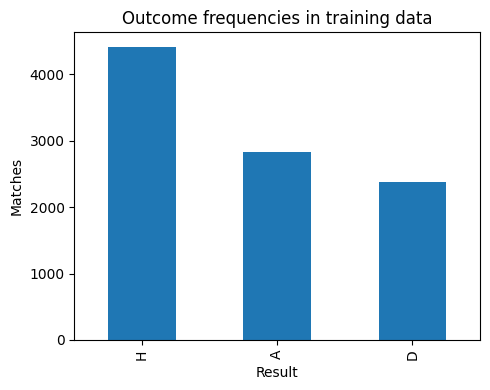

In [15]:
plt.figure(figsize=(5,4))
train_df["FTR"].value_counts().plot(kind="bar")
plt.title("Outcome frequencies in training data")
plt.ylabel("Matches")
plt.xlabel("Result")
plt.tight_layout()
plt.show()

In [16]:
# Load test data
epl_test = pd.read_csv(datapath + "epl-test.csv")

# Create a copy of the test data
test_df = epl_test.copy()

# Convert "Date" to datetime with mixed formats
test_df["Date"] = pd.to_datetime(test_df["Date"], format="mixed", dayfirst=True)

# Check final test_df
test_df

,Date,HomeTeam,AwayTeam
0,2026-01-31,Leeds,Arsenal
1,2026-01-31,Liverpool,Newcastle
2,2026-01-31,Tottenham,Man City
3,2026-01-31,Wolves,Bournemouth
4,2026-01-31,Aston Villa,Brentford
5,2026-01-31,Brighton,Everton
6,2026-01-31,Chelsea,West Ham
7,2026-01-31,Man United,Fulham
8,2026-01-31,Sunderland,Burnley
9,2026-01-31,Nottingham Forest,Crystal Palace


## Team Form and Rolling Averages (Last k matches)

This section focuses on engineering features that capture the recent performance or "form" of each team. In football analytics, a team's current form is a strong predictor of future match outcomes. By looking at a team's statistics over a set number of its most recent matches (e.g., the last k matches), we can quantify this form. The goal is to generate new features that reflect these rolling averages and sums for both home and away teams, without introducing data leakage (i.e., using future information to predict past events).

### Create `team_history` DataFrame
Transform match-level data into a team-centric format. For each match, it creates two entries in `team_history`: one from the perspective of the home team and one from the perspective of the away team.

After combining these, the DataFrame is sorted by `Team` and `Date` to ensure that rolling calculations are performed chronologically for each team. Derived columns like `GoalDiff` (Goals For - Goals Against) and `Points` (3 for a win, 1 for a draw, 0 for a loss) are also calculated for each team's match entry.

In [17]:
# Create team history function
def create_team_history(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create a unified team history DataFrame from match data.

    Combines home and away records into a single timeline per team,
    with goals, shots, and other stats from that team"s perspective.

    Parameters
    ----------
    df : pd.DataFrame
        Match data with columns: Date, HomeTeam, AwayTeam, Season, FTHG, FTAG, FTR,
        HS, AS, HST, AST, HF, AF, HC, AC

    Returns
    -------
    pd.DataFrame
        Team-level history sorted by (Team, Date) with columns:
        Date, Team, Season, GF, GA, FTR, Shots, ShotsOnTarget, Fouls, Corners,
        is_home, GoalDiff, Points
    """
    # Home team perspective
    home = df[["Date", "HomeTeam", "Season", "FTHG", "FTAG", "FTR", "HS", "HST", "HF", "HC"]].copy()
    home.rename(columns={
        "HomeTeam": "Team",
        "FTHG": "GF",     # goals for (GF)
        "FTAG": "GA",     # goals against (GA)
        "HS": "Shots",
        "HST": "ShotsOnTarget",
        "HF": "Fouls",
        "HC": "Corners"
    }, inplace=True)
    home["is_home"] = 1

    # Away team perspective
    away = df[["Date", "AwayTeam", "Season", "FTHG", "FTAG", "FTR", "AS", "AST", "AF", "AC"]].copy()
    away.rename(columns={
        "AwayTeam": "Team",
        "FTAG": "GF",     # goals for (GF)
        "FTHG": "GA",     # goals against (GA)
        "AS": "Shots",
        "AST": "ShotsOnTarget",
        "AF": "Fouls",
        "AC": "Corners"
    }, inplace=True)
    away["is_home"] = 0

    # Combine and sort
    team_history = (
        pd.concat([home, away], ignore_index=True)
        .sort_values(["Team", "Date"])
        .reset_index(drop=True)
    )

    # Derived columns
    team_history["GoalDiff"] = team_history["GF"] - team_history["GA"]
    team_history["Points"] = (
        (team_history["GF"] > team_history["GA"]).astype(int) * 3
        + (team_history["GF"] == team_history["GA"]).astype(int) * 1
        # 3 points for win, 1 for draw, 0 for loss
        # losses automatically get 0
    )

    return team_history

In [18]:
# Create team history DataFrame
team_history = create_team_history(train_df)
team_history

,Date,Team,Season,GF,GA,FTR,Shots,ShotsOnTarget,Fouls,Corners,is_home,GoalDiff,Points
0,2000-08-19,Arsenal,2000,0.0,1.0,H,14.0,7.0,21.0,9.0,0,-1.0,0
1,2000-08-21,Arsenal,2000,2.0,0.0,H,17.0,12.0,25.0,10.0,1,2.0,3
2,2000-08-26,Arsenal,2000,5.0,3.0,H,18.0,9.0,12.0,8.0,1,2.0,3
3,2000-09-06,Arsenal,2000,2.0,2.0,D,13.0,5.0,22.0,6.0,0,0.0,1
4,2000-09-09,Arsenal,2000,1.0,1.0,D,18.0,11.0,13.0,10.0,0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19235,2025-10-18,Wolves,2025,0.0,2.0,H,16.0,3.0,12.0,2.0,0,-2.0,0
19236,2025-10-26,Wolves,2025,2.0,3.0,A,15.0,7.0,12.0,5.0,1,-1.0,0
19237,2025-11-01,Wolves,2025,0.0,3.0,H,5.0,2.0,14.0,1.0,0,-3.0,0
19238,2025-11-08,Wolves,2025,0.0,3.0,H,3.0,0.0,14.0,1.0,0,-3.0,0


### Calculating Rolling Sums and Means

For a defined window `k` (e.g., `k=5` for the last 5 matches), rolling statistics are computed:

-   **Grouping by Team**: The `team_history` DataFrame is grouped by `Team`. This is essential because we want to calculate rolling statistics for *each team independently*.
-   **`shift(1)`**: Before applying the rolling window, `shift(1)` is used. This is a critical step to prevent data leakage. It ensures that when calculating the form for a particular match, only statistics from *previous* matches are considered, not the current match's outcome.
-   **Rolling Sums**: For metrics like `GF`, `GA`, and `Points`, the sum over the last `k` matches is calculated (e.g., `GF_sum_last_10`). `min_periods=1` ensures that even if a team has played fewer than `k` matches, the sum is still calculated based on available data.
-   **Rolling Means**: For `GF`, `GA`, `GoalDiff`, `Shots`, `ShotsOnTarget`, and `Corners`, the mean (average) over the last `k` matches is calculated (e.g., `GF_mean_last_10`). `min_periods=1` ensures that even if a team has played fewer than `k` matches, the mean is still calculated based on available data.This provides an average performance indicator.

In [19]:
k = 10  # number of previous matches to look back over

# Group by team, because we want each team’s history separately
grp = team_history.groupby("Team", group_keys=False)

In [20]:
# Rolling sums for GF, GA, Points over last k matches (excluding current match)
for col in ["GF", "GA", "Points"]:
    team_history[f"{col}_sum_last_{k}"] = grp[col].apply(
        lambda s: s.shift(1).rolling(window=k, min_periods=1).sum()   # shift(1) to exclude current match
    )

team_history

,Date,Team,Season,GF,GA,FTR,Shots,ShotsOnTarget,Fouls,Corners,is_home,GoalDiff,Points,GF_sum_last_10,GA_sum_last_10,Points_sum_last_10
0,2000-08-19,Arsenal,2000,0.0,1.0,H,14.0,7.0,21.0,9.0,0,-1.0,0,NaN,NaN,NaN
1,2000-08-21,Arsenal,2000,2.0,0.0,H,17.0,12.0,25.0,10.0,1,2.0,3,0.0,1.0,0.0
2,2000-08-26,Arsenal,2000,5.0,3.0,H,18.0,9.0,12.0,8.0,1,2.0,3,2.0,1.0,3.0
3,2000-09-06,Arsenal,2000,2.0,2.0,D,13.0,5.0,22.0,6.0,0,0.0,1,7.0,4.0,6.0
4,2000-09-09,Arsenal,2000,1.0,1.0,D,18.0,11.0,13.0,10.0,0,0.0,1,9.0,6.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19235,2025-10-18,Wolves,2025,0.0,2.0,H,16.0,3.0,12.0,2.0,0,-2.0,0,8.0,21.0,3.0
19236,2025-10-26,Wolves,2025,2.0,3.0,A,15.0,7.0,12.0,5.0,1,-1.0,0,8.0,21.0,3.0
19237,2025-11-01,Wolves,2025,0.0,3.0,H,5.0,2.0,14.0,1.0,0,-3.0,0,8.0,20.0,3.0
19238,2025-11-08,Wolves,2025,0.0,3.0,H,3.0,0.0,14.0,1.0,0,-3.0,0,7.0,22.0,2.0


In [21]:
# Rolling means for GF, GA, GoalDiff, Shots, ShotsOnTarget, Corners over last k matches (excluding current match)
for col in ["GF", "GA", "GoalDiff", "Shots", "ShotsOnTarget", "Corners"]:
    team_history[f"{col}_mean_last_{k}"] = grp[col].apply(
        lambda s: s.shift(1).rolling(window=k, min_periods=1).mean()
    )

team_history

,Date,Team,Season,GF,GA,FTR,Shots,ShotsOnTarget,Fouls,Corners,...,Points,GF_sum_last_10,GA_sum_last_10,Points_sum_last_10,GF_mean_last_10,GA_mean_last_10,GoalDiff_mean_last_10,Shots_mean_last_10,ShotsOnTarget_mean_last_10,Corners_mean_last_10
0,2000-08-19,Arsenal,2000,0.0,1.0,H,14.0,7.0,21.0,9.0,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000-08-21,Arsenal,2000,2.0,0.0,H,17.0,12.0,25.0,10.0,...,3,0.0,1.0,0.0,0.000000,1.000000,-1.00,14.000000,7.000000,9.00
2,2000-08-26,Arsenal,2000,5.0,3.0,H,18.0,9.0,12.0,8.0,...,3,2.0,1.0,3.0,1.000000,0.500000,0.50,15.500000,9.500000,9.50
3,2000-09-06,Arsenal,2000,2.0,2.0,D,13.0,5.0,22.0,6.0,...,1,7.0,4.0,6.0,2.333333,1.333333,1.00,16.333333,9.333333,9.00
4,2000-09-09,Arsenal,2000,1.0,1.0,D,18.0,11.0,13.0,10.0,...,1,9.0,6.0,7.0,2.250000,1.500000,0.75,15.500000,8.250000,8.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19235,2025-10-18,Wolves,2025,0.0,2.0,H,16.0,3.0,12.0,2.0,...,0,8.0,21.0,3.0,0.800000,2.100000,-1.30,10.600000,3.500000,5.10
19236,2025-10-26,Wolves,2025,2.0,3.0,A,15.0,7.0,12.0,5.0,...,0,8.0,21.0,3.0,0.800000,2.100000,-1.30,11.200000,3.500000,4.50
19237,2025-11-01,Wolves,2025,0.0,3.0,H,5.0,2.0,14.0,1.0,...,0,8.0,20.0,3.0,0.800000,2.000000,-1.20,11.500000,3.900000,4.20
19238,2025-11-08,Wolves,2025,0.0,3.0,H,3.0,0.0,14.0,1.0,...,0,7.0,22.0,2.0,0.700000,2.200000,-1.50,10.200000,3.500000,3.60


At this point, team_history has, for each (Team, Date), features like:
    `GF_sum_last_10`, `GA_sum_last_10`, `Points_sum_last_10`,
    `GF_mean_last_10`, `GA_mean_last_10`, `GoalDiff_mean_last_10`, ...

The first match for each team will have NaNs
because they don"t have k previous games.

### Spltting and Merging Form Features

After computing the rolling statistics, the `team_history` DataFrame (specifically, the `team_feats` subset containing the `Team`, `Date`, `is_home`, and all the `_last_k` features) is split back into `home_feats` and `away_feats` based on the `is_home` flag. These are then merged with the original `train_df` on `Date` and `HomeTeam`/`AwayTeam` respectively. Prefixing the columns (e.g., `home_GF_sum_last_10`, `away_GF_sum_last_10`) ensures that we can easily distinguish between the home team's and away team's form features.

In [22]:
# Pick just the columns we care about
rolling_cols = [c for c in team_history.columns if f"last_{k}" in c]
base_cols = ["Date", "Season", "Team", "is_home"]

team_feats = team_history[base_cols + rolling_cols].copy()

team_feats

,Date,Season,Team,is_home,GF_sum_last_10,GA_sum_last_10,Points_sum_last_10,GF_mean_last_10,GA_mean_last_10,GoalDiff_mean_last_10,Shots_mean_last_10,ShotsOnTarget_mean_last_10,Corners_mean_last_10
0,2000-08-19,2000,Arsenal,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000-08-21,2000,Arsenal,1,0.0,1.0,0.0,0.000000,1.000000,-1.00,14.000000,7.000000,9.00
2,2000-08-26,2000,Arsenal,1,2.0,1.0,3.0,1.000000,0.500000,0.50,15.500000,9.500000,9.50
3,2000-09-06,2000,Arsenal,0,7.0,4.0,6.0,2.333333,1.333333,1.00,16.333333,9.333333,9.00
4,2000-09-09,2000,Arsenal,0,9.0,6.0,7.0,2.250000,1.500000,0.75,15.500000,8.250000,8.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19235,2025-10-18,2025,Wolves,0,8.0,21.0,3.0,0.800000,2.100000,-1.30,10.600000,3.500000,5.10
19236,2025-10-26,2025,Wolves,1,8.0,21.0,3.0,0.800000,2.100000,-1.30,11.200000,3.500000,4.50
19237,2025-11-01,2025,Wolves,0,8.0,20.0,3.0,0.800000,2.000000,-1.20,11.500000,3.900000,4.20
19238,2025-11-08,2025,Wolves,0,7.0,22.0,2.0,0.700000,2.200000,-1.50,10.200000,3.500000,3.60


In [23]:
# Split into home and away versions
home_feats = (
    team_feats[team_feats["is_home"] == 1]
    .drop(columns=["is_home"])
    .sort_values(["Team", "Date"])
)

away_feats = (
    team_feats[team_feats["is_home"] == 0]
    .drop(columns=["is_home"])
    .sort_values(["Team", "Date"])
)

In [24]:
# Make a fresh copy of the original match-level df (with Date as datetime)
matches_with_form = train_df.copy()
matches_with_form["Date"] = pd.to_datetime(matches_with_form["Date"], dayfirst=True)

In [25]:
# Merge home form: match (Date, HomeTeam) <-> (home_Date, home_Team)
matches_with_form = matches_with_form.merge(
    home_feats.add_prefix("home_"),
    left_on=["Date", "HomeTeam"],
    right_on=["home_Date", "home_Team"],
    how="left"
)

# Merge away form: match (Date, AwayTeam) <-> (away_Date, away_Team)
matches_with_form = matches_with_form.merge(
    away_feats.add_prefix("away_"),
    left_on=["Date", "AwayTeam"],
    right_on=["away_Date", "away_Team"],
    how="left"
)

### Calculating Difference Features

To create features that directly compare the form of the home and away teams for a given match, difference metrics are computed:

-   `points_form_diff_last_10`: The difference in points accumulated by the home team versus the away team over their last `k` matches.
-   `goal_diff_form_last_10`: The difference in goal difference (goals scored minus goals conceded) between the home and away teams over their last `k` matches.

These difference features are often highly predictive, as they directly compare the relative strengths of the two competing teams.

In [26]:
# Calculate differences in form features
matches_with_form["points_diff_last_10"] = (
    matches_with_form["home_Points_sum_last_10"]
    - matches_with_form["away_Points_sum_last_10"]
)

matches_with_form["goal_diff_last_10"] = (
    matches_with_form["home_GF_sum_last_10"] - matches_with_form["home_GA_sum_last_10"]
    - (matches_with_form["away_GF_sum_last_10"] - matches_with_form["away_GA_sum_last_10"])
)

### Column Cleanup

Finally, any original match statistics (`FTHG`, `FTAG`, etc.) and intermediate columns used solely for merging (`home_Date`, `home_Team`, etc.) are dropped. This leaves a clean DataFrame (`matches_with_form`) containing the original match identifiers (`Date`, `Season`, `HomeTeam`, `AwayTeam`) along with the newly engineered form features, ready for further combination with other feature sets.

In [27]:
# Drop unneeded columns
matches_with_form = matches_with_form.drop(columns=["FTHG", "FTAG", "FTR", "HTHG", "HTAG",
              "HTR", "Referee", "HS", "AS", "HST", "AST", "HC", "AC", "HF", "AF","HY", "AY",
              "HR", "AR", "home_Date", "home_Team", "away_Date", "away_Team","home_Season",
              "away_Season"])

In [28]:
# Final matches with form features
matches_with_form

,Date,Season,HomeTeam,AwayTeam,FTR_encoded,home_GF_sum_last_10,home_GA_sum_last_10,home_Points_sum_last_10,home_GF_mean_last_10,home_GA_mean_last_10,...,away_GA_sum_last_10,away_Points_sum_last_10,away_GF_mean_last_10,away_GA_mean_last_10,away_GoalDiff_mean_last_10,away_Shots_mean_last_10,away_ShotsOnTarget_mean_last_10,away_Corners_mean_last_10,points_diff_last_10,goal_diff_last_10
0,2000-08-19,2000,Charlton,Man City,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000-08-19,2000,Chelsea,West Ham,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2000-08-19,2000,Coventry,Middlesbrough,2,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2000-08-19,2000,Derby,Southampton,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2000-08-19,2000,Leeds,Everton,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9615,2025-11-22,2025,Brighton,Brentford,0,16.0,14.0,15.0,1.6,1.4,...,14.0,16.0,1.6,1.4,0.2,10.7,4.6,5.4,-1.0,0.0
9616,2025-11-22,2025,Newcastle,Man City,0,11.0,14.0,11.0,1.1,1.4,...,8.0,19.0,1.9,0.8,1.1,13.7,5.3,5.9,-8.0,-14.0
9617,2025-11-23,2025,Arsenal,Tottenham,0,19.0,5.0,23.0,1.9,0.5,...,10.0,15.0,1.6,1.0,0.6,9.0,3.2,6.1,8.0,8.0
9618,2025-11-23,2025,Leeds,Aston Villa,2,9.0,20.0,8.0,0.9,2.0,...,10.0,17.0,1.3,1.0,0.3,11.6,3.6,5.6,-9.0,-14.0


In [29]:
# Check columns
matches_with_form.drop(columns=['home_GF_sum_last_10',
       'home_GA_sum_last_10', 'home_Points_sum_last_10', 'home_GF_mean_last_10',
       'home_GA_mean_last_10', 'home_GoalDiff_mean_last_10', 'home_Shots_mean_last_10', 'home_ShotsOnTarget_mean_last_10',
       'home_Corners_mean_last_10', 'away_GF_sum_last_10', 'away_GA_sum_last_10',
       'away_Points_sum_last_10', 'away_GF_mean_last_10', 'away_GA_mean_last_10',
       'away_GoalDiff_mean_last_10', 'away_Shots_mean_last_10', 'away_ShotsOnTarget_mean_last_10', 'away_Corners_mean_last_10'])

,Date,Season,HomeTeam,AwayTeam,FTR_encoded,points_diff_last_10,goal_diff_last_10
0,2000-08-19,2000,Charlton,Man City,0,NaN,NaN
1,2000-08-19,2000,Chelsea,West Ham,0,NaN,NaN
2,2000-08-19,2000,Coventry,Middlesbrough,2,NaN,NaN
3,2000-08-19,2000,Derby,Southampton,1,NaN,NaN
4,2000-08-19,2000,Leeds,Everton,0,NaN,NaN
...,...,...,...,...,...,...,...
9615,2025-11-22,2025,Brighton,Brentford,0,-1.0,0.0
9616,2025-11-22,2025,Newcastle,Man City,0,-8.0,-14.0
9617,2025-11-23,2025,Arsenal,Tottenham,0,8.0,8.0
9618,2025-11-23,2025,Leeds,Aston Villa,2,-9.0,-14.0


### Visualising Distributions of Rolling Average Features

In [30]:
key_form_cols = ["points_diff_last_10", "goal_diff_last_10"]
display(matches_with_form[key_form_cols].describe())

,points_diff_last_10,goal_diff_last_10
count,9585.000000,9585.000000
mean,-0.238185,-0.326969
std,7.901425,11.540374
min,-28.000000,-51.000000
25%,-6.000000,-8.000000
50%,0.000000,0.000000
75%,5.000000,7.000000
max,28.000000,51.000000


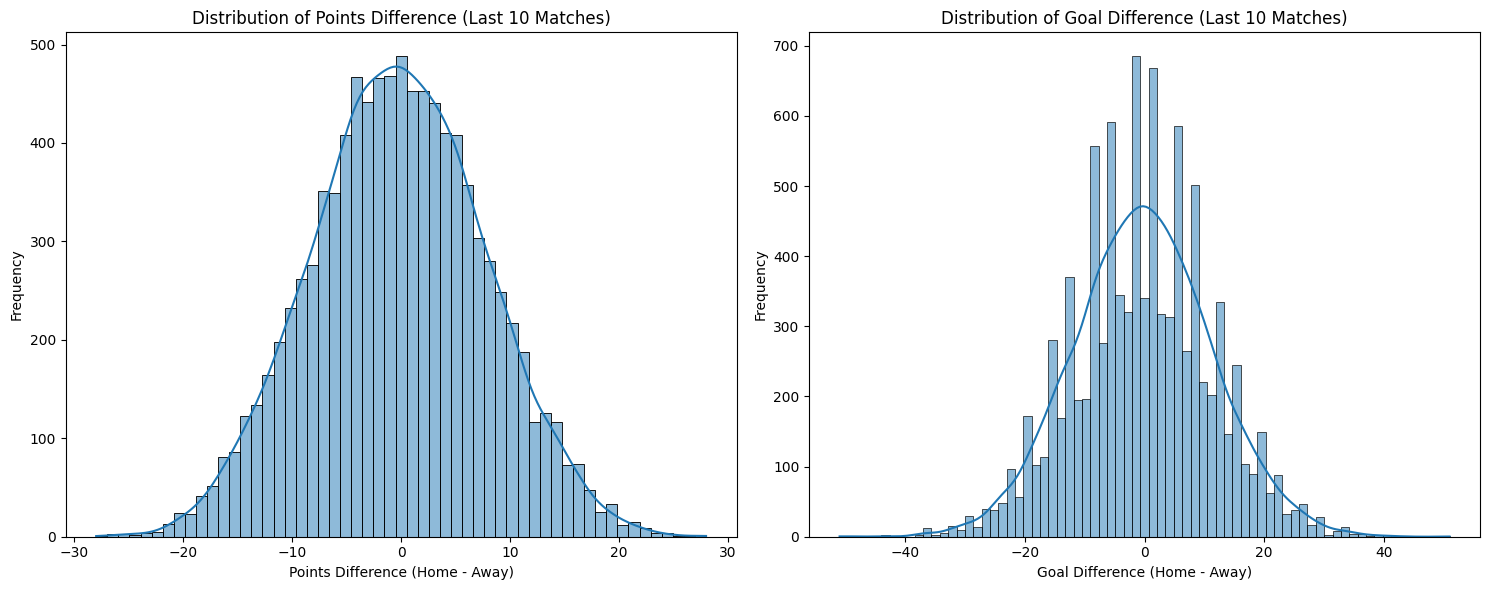

In [31]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(matches_with_form['points_diff_last_10'], kde=True)
plt.title('Distribution of Points Difference (Last 10 Matches)')
plt.xlabel('Points Difference (Home - Away)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(matches_with_form['goal_diff_last_10'], kde=True)
plt.title('Distribution of Goal Difference (Last 10 Matches)')
plt.xlabel('Goal Difference (Home - Away)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Correlation of Rolling Average Features with FTR


Correlation of Form Features with FTR_encoded:
Correlation of Rolling Average Features with FTR_encoded:


,FTR_encoded
FTR_encoded,1.000000
away_GoalDiff_mean_last_10,0.232613
away_Shots_mean_last_10,0.228560
away_Points_sum_last_10,0.220852
away_GF_sum_last_10,0.212642
away_GF_mean_last_10,0.211351
home_GA_mean_last_10,0.181326
home_GA_sum_last_10,0.176375
away_ShotsOnTarget_mean_last_10,0.163093
away_Corners_mean_last_10,0.119726


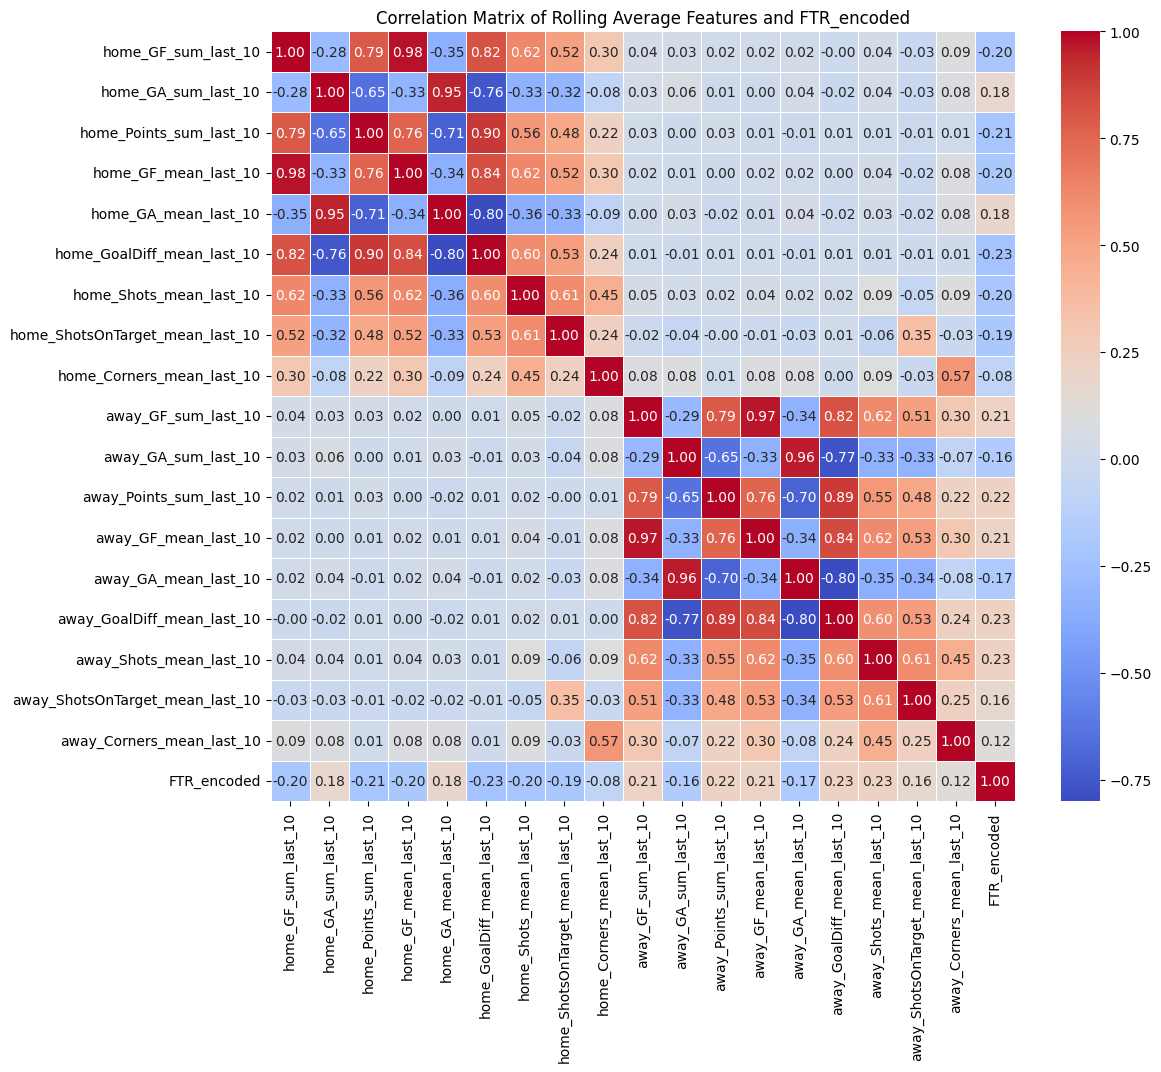

In [32]:
print("\nCorrelation of Form Features with FTR_encoded:")
# Select relevant rolling average features and the target variable
rolling_features = [
    col for col in matches_with_form.columns if '_last_10' in col and col not in key_form_cols
]

correlation_df = matches_with_form[rolling_features + ['FTR_encoded']]

# Calculate the correlation matrix
correlation_matrix = correlation_df.corr()

# Display correlations with FTR_encoded
print("Correlation of Rolling Average Features with FTR_encoded:")
display(correlation_matrix['FTR_encoded'].sort_values(ascending=False))

# Optionally, visualize the correlation matrix for these features
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Rolling Average Features and FTR_encoded')
plt.show()

## Exponentially Weighted Moving Averages

This section builds upon the concept of team form by introducing Exponentially Weighted Moving Averages (EWMA). While simple rolling averages treat all matches within the window equally, EWMA gives more weight to recent matches and less to older ones. This can be particularly useful in dynamic environments like football, where a team's current performance is often a better indicator than its performance several matches ago.

### Creating `team_history` DataFrame

Similar to the rolling averages section, the process begins by creating the `team_history` DataFrame using the `create_team_history` function. This function transforms the match-level data into a team-centric format, calculating goals for (`GF`), goals against (`GA`), goal difference (`GoalDiff`), and points (`Points`) for each team in every match.

In [33]:
# Create team history DataFrame
team_history = create_team_history(train_df)

### Calculating EWMA Statistics

For EWMA, a `span` parameter (e.g., `span=8`) is defined, which controls the decay rate: a smaller span means recent observations have a greater impact. The calculations are performed as follows:

-   **Grouping by Team**: The `team_history` DataFrame is grouped by `Team` to ensure EWMA is computed independently for each team.
-   **`ewm_shifted` Function**: A helper function `ewm_shifted` is used:
    -   `s.shift(1)`: This is crucial for preventing data leakage. It ensures that the EWMA for a given match only considers data from *previous* matches, not the match itself.
    -   `ewm(span=span, adjust=False).mean()`: This applies the Exponentially Weighted Moving Average. `adjust=False` uses a simpler weighting calculation that is often preferred for time series analysis.
-   **Selected Statistics**: EWMA is applied to key performance indicators such as `GF`, `GA`, `GoalDiff`, `Points`, `Shots`, `ShotsOnTarget`, `Fouls`, and `Corners`, resulting in new columns like `GF_ewm`, `GA_ewm`, etc.

In [34]:
# More recent matches are weighted more heavily.
# span controls decay speed; smaller span = faster decay.
span = 8  # hyperparameter; we can tune this

alpha = 2 / (span + 1)
print(f"Using EWMA span={span}, alpha={alpha:.3f}")

grp = team_history.groupby("Team", group_keys=False)

def ewm_shifted(col_name: str, span: int) -> pd.Series:
    """
    For each team, compute EWM over *past* matches only:
    - shift(1) so current match is NOT included (no leakage)
    - ewm(span=span) to weight recent history more.
    """
    return grp[col_name].apply(
        lambda s: s.shift(1).ewm(span=span, adjust=False).mean()
    )

# Choose which stats to smooth
ewm_source_cols = ["GF", "GA", "GoalDiff", "Points",
                   "Shots", "ShotsOnTarget", "Fouls", "Corners"]

for col in ewm_source_cols:
    team_history[f"{col}_ewm"] = ewm_shifted(col, span)

Using EWMA span=8, alpha=0.222


For `span=8`, the smoothing factor (alpha) is calculated as:

$$\alpha = \frac{2}{span + 1} = \frac{2}{8 + 1} = \frac{2}{9} \approx 0.2222$$

So, an `alpha` of approximately 0.2222 means that the most recent observation contributes about **22.22%** to the new EWMA, while the previous EWMA value contributes about **(1 - 0.2222) = 77.78%**. Hence,

$$\text{New EWMA} = (0.2222 \times \text{Current Observation}) + (0.7778 \times \text{Previous EWMA})$$

This gives significant weight to recent data points, making the average responsive to current trends.

### Splitting and Merging EWMA Features

After EWMA values are calculated and added to `team_history`, the `team_feats` DataFrame (containing the `Date`, `Team`, `is_home`, and all the newly created `_ewm` columns) is filtered and split into `home_feats` (where `is_home == 1`) and `away_feats` (where `is_home == 0`), with the `is_home` column subsequently dropped. To maintain clarity and prevent naming conflicts, columns in `home_feats` are prefixed with `home_` (e.g., `home_GF_ewm`), and similarly for `away_feats` with `away_`. These prefixed home and away EWMA features are then merged back into a copy of the original match DataFrame (`matches_with_ewm`), using `Date` and `HomeTeam`/`AwayTeam` as the respective keys for the merge operations. This ensures that each match entry is enriched with the relevant exponentially weighted performance metrics for both participating teams.

In [35]:
# Columns we need from team_history to join back
ewm_cols = [c for c in team_history.columns if c.endswith("_ewm")]
base_cols = ["Date", "Team", "is_home"]

team_feats = team_history[base_cols + ewm_cols].copy()

# Split into home and away feature tables
home_feats = team_feats[team_feats["is_home"] == 1].drop(columns=["is_home"])
away_feats = team_feats[team_feats["is_home"] == 0].drop(columns=["is_home"])

# Prefix columns so they stay distinct
home_feats = home_feats.add_prefix("home_")
away_feats = away_feats.add_prefix("away_")

# Fresh copy of the original match-level data
matches_with_ewm = train_df.copy()
matches_with_ewm["Date"] = pd.to_datetime(matches_with_ewm["Date"], dayfirst=True)

# Merge home EWMA features: (Date, HomeTeam) <-> (home_Date, home_Team)
matches_with_ewm = matches_with_ewm.merge(
    home_feats,
    left_on=["Date", "HomeTeam"],
    right_on=["home_Date", "home_Team"],
    how="left"
)

# Merge away EWMA features: (Date, AwayTeam) <-> (away_Date, away_Team)
matches_with_ewm = matches_with_ewm.merge(
    away_feats,
    left_on=["Date", "AwayTeam"],
    right_on=["away_Date", "away_Team"],
    how="left"
)

# Remove duplicate key columns from the merge
matches_with_ewm = matches_with_ewm.drop(
    columns=["home_Date", "home_Team", "away_Date", "away_Team"]
)

### Calculating Difference Features

To capture the relative strength of the home and away teams based on their EWMA forms, difference features are calculated:

-   `ewm_points_diff`: The difference between the home team's EWMA Points and the away team's EWMA Points.
-   `ewm_goal_diff`: The difference between the home team's EWMA GoalDiff and the away team's EWMA GoalDiff.
-   `ewm_points_abs_diff`: The absolute difference between the home team's EWMA Points and the away team's EWMA Points, measuring the magnitude of the point difference.
-   `ewm_goal_abs_diff`: The absolute difference between the home team's EWMA GoalDiff and the away team's EWMA GoalDiff, indicating the magnitude of the goal difference.
-   `ewm_points_balanced_flag`: A binary flag set to 1 if the absolute EWMA points difference is below a certain threshold (e.g., 0.4), indicating that the teams have very similar recent form in terms of points.
-   `ewm_att_total`: The sum of the home team's EWMA Goals For and the away team's EWMA Goals For, representing the combined offensive strength.
-   `ewm_def_total`: The sum of the home team's EWMA Goals Against and the away team's EWMA Goals Against, representing the combined defensive vulnerability.
-   `ewm_shots_total`: The sum of the home team's EWMA Shots and the away team's EWMA Shots, indicating the combined shot volume.
-   `ewm_sot_total`: The sum of the home team's EWMA Shots On Target and the away team's EWMA Shots On Target, indicating combined accuracy of shots.

These features directly compare the smoothed recent performance of the two teams, offering additional insights into their relative strengths and weaknesses.

In [36]:
# Calculate differences in EWMA features
matches_with_ewm["ewm_points_diff"] = (
    matches_with_ewm["home_Points_ewm"] - matches_with_ewm["away_Points_ewm"]
)

matches_with_ewm["ewm_goal_diff"] = (
    matches_with_ewm["home_GoalDiff_ewm"] - matches_with_ewm["away_GoalDiff_ewm"]
)

In [37]:
# Calculate the absolute differences for EWMA points and goal differences
matches_with_ewm["ewm_points_abs_diff"] = matches_with_ewm["ewm_points_diff"].abs()
matches_with_ewm["ewm_goal_abs_diff"] = matches_with_ewm["ewm_goal_diff"].abs()

In [38]:
# "Balanced form" indicator: 1 if teams' EWMA points are very similar
matches_with_ewm["ewm_points_balanced_flag"] = (
    matches_with_ewm["ewm_points_abs_diff"] < 0.4
).astype(int)

In [39]:
# Calculate combined offensive and defensive EWMA statistics
matches_with_ewm["ewm_att_total"] = (
    matches_with_ewm["home_GF_ewm"] + matches_with_ewm["away_GF_ewm"]
)
matches_with_ewm["ewm_def_total"] = (
    matches_with_ewm["home_GA_ewm"] + matches_with_ewm["away_GA_ewm"]
)

In [40]:
# Calculate combined EWMA Shots and ShotsOnTarget statistics
if "home_Shots_ewm" in matches_with_ewm.columns:
  matches_with_ewm["ewm_shots_total"] = (
      matches_with_ewm["home_Shots_ewm"] + matches_with_ewm["away_Shots_ewm"]
  )

if "home_ShotsOnTarget_ewm" in matches_with_ewm.columns:
  matches_with_ewm["ewm_sot_total"] = (
      matches_with_ewm["home_ShotsOnTarget_ewm"]
      + matches_with_ewm["away_ShotsOnTarget_ewm"]
  )

### Column Cleanup

Finally, any original match statistics (`FTHG`, `FTAG`, etc.) and intermediate columns used solely for merging (`home_Date`, `home_Team`, etc.) are dropped. This results in a clean `matches_with_ewm` DataFrame containing the original match identifiers along with the newly engineered EWMA features, ready for further combination.

In [41]:
# Drop unneeded columns
matches_with_ewm = matches_with_ewm.drop(columns=["FTHG", "FTAG", "FTR", "HTHG", "HTAG",
              "HTR", "Referee", "HS", "AS", "HST", "AST", "HC", "AC", "HF", "AF","HY", "AY",
              "HR", "AR", "ewm_points_abs_diff", "ewm_goal_abs_diff"])

In [42]:
# Final matches with EWMA features
matches_with_ewm

,Date,Season,HomeTeam,AwayTeam,FTR_encoded,home_GF_ewm,home_GA_ewm,home_GoalDiff_ewm,home_Points_ewm,home_Shots_ewm,...,away_ShotsOnTarget_ewm,away_Fouls_ewm,away_Corners_ewm,ewm_points_diff,ewm_goal_diff,ewm_points_balanced_flag,ewm_att_total,ewm_def_total,ewm_shots_total,ewm_sot_total
0,2000-08-19,2000,Charlton,Man City,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
1,2000-08-19,2000,Chelsea,West Ham,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
2,2000-08-19,2000,Coventry,Middlesbrough,2,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
3,2000-08-19,2000,Derby,Southampton,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
4,2000-08-19,2000,Leeds,Everton,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9615,2025-11-22,2025,Brighton,Brentford,0,1.639167,1.150415,0.488752,1.620303,12.431995,...,5.153558,10.123229,5.981486,-0.163771,0.118734,1,3.415914,2.557144,24.531279,9.951952
9616,2025-11-22,2025,Newcastle,Man City,0,1.163244,1.784644,-0.621400,0.941576,11.771573,...,5.766489,10.177123,6.996594,-1.365352,-2.237575,0,3.336189,2.341414,26.640891,9.570601
9617,2025-11-23,2025,Arsenal,Tottenham,0,1.722160,0.651863,1.070297,2.302693,14.973738,...,3.105863,10.556334,6.504554,1.062200,0.787485,0,3.265625,1.912516,23.247298,8.713624
9618,2025-11-23,2025,Leeds,Aston Villa,2,0.939764,2.206250,-1.266486,0.719913,11.541721,...,4.359612,8.775003,5.396408,-1.325376,-2.175263,0,2.659736,3.017445,23.087554,7.917194


In [43]:
# Check columns
matches_with_ewm.columns

Index(['Date', 'Season', 'HomeTeam', 'AwayTeam', 'FTR_encoded', 'home_GF_ewm',
       'home_GA_ewm', 'home_GoalDiff_ewm', 'home_Points_ewm', 'home_Shots_ewm',
       'home_ShotsOnTarget_ewm', 'home_Fouls_ewm', 'home_Corners_ewm',
       'away_GF_ewm', 'away_GA_ewm', 'away_GoalDiff_ewm', 'away_Points_ewm',
       'away_Shots_ewm', 'away_ShotsOnTarget_ewm', 'away_Fouls_ewm',
       'away_Corners_ewm', 'ewm_points_diff', 'ewm_goal_diff',
       'ewm_points_balanced_flag', 'ewm_att_total', 'ewm_def_total',
       'ewm_shots_total', 'ewm_sot_total'],
      dtype='object')

### Visualising Distributions of EWMA Features

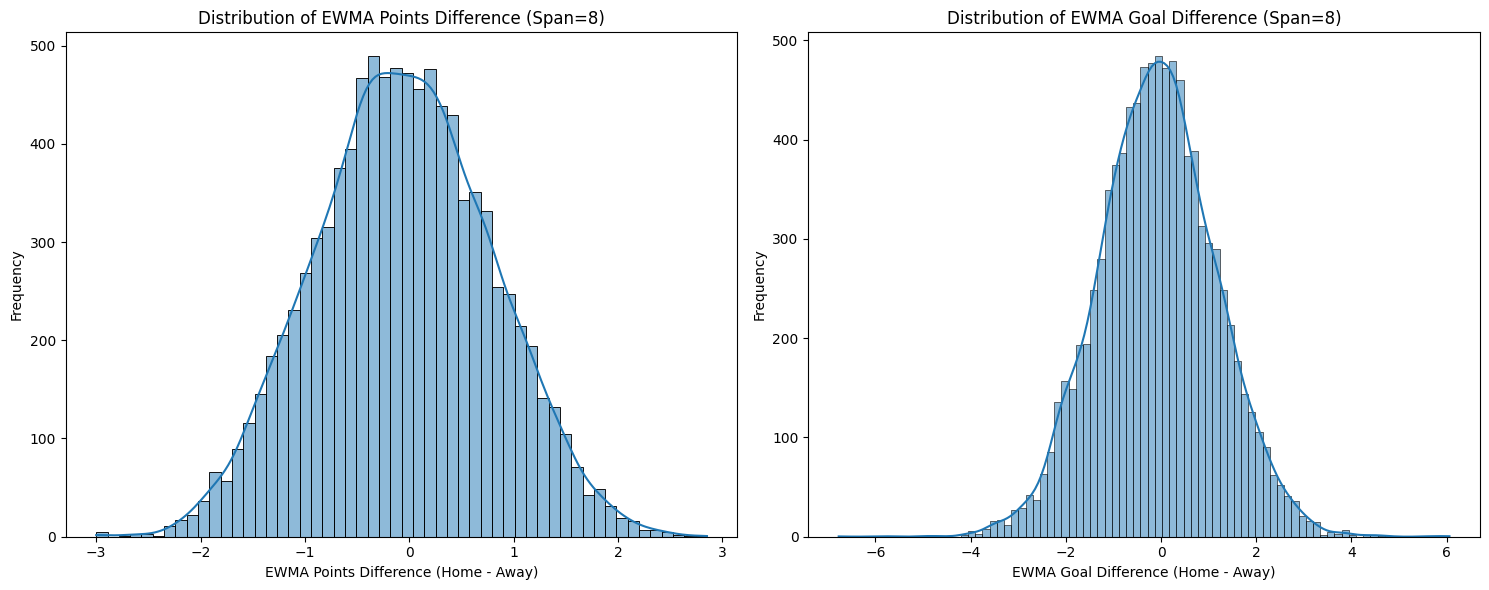

In [44]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(matches_with_ewm['ewm_points_diff'], kde=True)
plt.title('Distribution of EWMA Points Difference (Span=8)')
plt.xlabel('EWMA Points Difference (Home - Away)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(matches_with_ewm['ewm_goal_diff'], kde=True)
plt.title('Distribution of EWMA Goal Difference (Span=8)')
plt.xlabel('EWMA Goal Difference (Home - Away)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Correlation of EWMA Features with FTR


Correlation of EWMA Features with FTR_encoded:


,FTR_encoded
FTR_encoded,1.000000
away_GoalDiff_ewm,0.228169
away_Shots_ewm,0.224360
away_Points_ewm,0.210645
away_GF_ewm,0.201970
home_GA_ewm,0.168373
away_ShotsOnTarget_ewm,0.161789
away_Corners_ewm,0.117820
home_Fouls_ewm,0.011560
away_Fouls_ewm,-0.067182


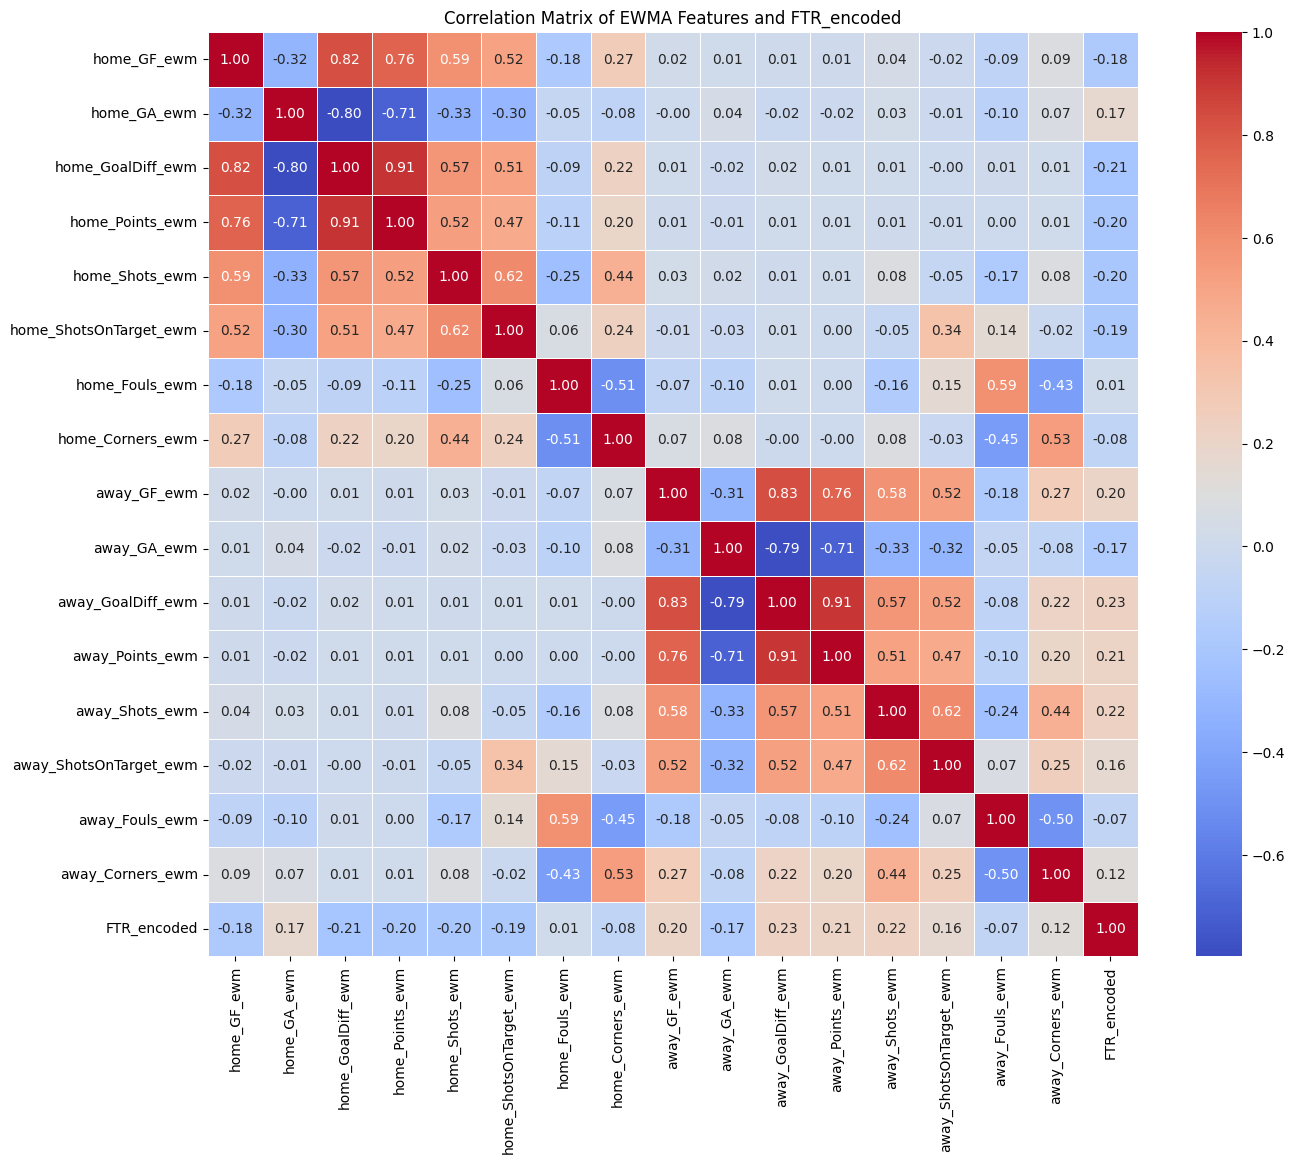

In [45]:
print("\nCorrelation of EWMA Features with FTR_encoded:")
# Select relevant EWMA features and the target variable
ewma_features = [
    col for col in matches_with_ewm.columns if '_ewm' in col and col not in ['ewm_points_diff',
      'ewm_goal_diff', 'ewm_points_abs_diff', 'ewm_goal_abs_diff','ewm_points_balanced_flag',
      'ewm_att_total', 'ewm_def_total', 'ewm_shots_total', 'ewm_sot_total']
]

correlation_df_ewm = matches_with_ewm[ewma_features + ['FTR_encoded']]

# Calculate the correlation matrix
correlation_matrix_ewm = correlation_df_ewm.corr()

# Display correlations with FTR_encoded
display(correlation_matrix_ewm['FTR_encoded'].sort_values(ascending=False))

# Optionally, visualize the correlation matrix for these features
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix_ewm, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of EWMA Features and FTR_encoded')
plt.show()

In [46]:
ewm_vs_form = pd.DataFrame({
    "points_diff_last_10": matches_with_form["points_diff_last_10"],
    "goal_diff_last_10": matches_with_form["goal_diff_last_10"],
    "ewm_points_diff": matches_with_ewm["ewm_points_diff"],
    "ewm_goal_diff": matches_with_ewm["ewm_goal_diff"],
    "ewm_att_total": matches_with_ewm["ewm_att_total"],
    "ewm_def_total": matches_with_ewm["ewm_def_total"],
    "ewm_shots_total": matches_with_ewm["ewm_shots_total"],
    "ewm_sot_total": matches_with_ewm["ewm_sot_total"],
    "FTR_encoded": train_df["FTR_encoded"],
}).dropna()

corr_matrix = ewm_vs_form.corr()
display(corr_matrix["FTR_encoded"].sort_values(ascending=False))

,FTR_encoded
FTR_encoded,1.000000
ewm_shots_total,0.019336
ewm_att_total,0.017731
ewm_def_total,0.003710
ewm_sot_total,-0.013705
ewm_points_diff,-0.292705
points_diff_last_10,-0.312022
ewm_goal_diff,-0.315188
goal_diff_last_10,-0.333686


## Elo Ratings

This section introduces the Elo rating system to quantify the skill level of each team over time. The Elo system is a method for calculating the relative skill levels of players (or teams) in competitor-versus-competitor games. It is dynamic, meaning ratings change after each match based on the outcome, providing a continuous measure of a team's strength. Key parameters like `base_rating`, `k_factor`, `home_advantage`, and `use_goal_diff_multiplier` allow for customization of the system to fit football data.

### `add_elo_features` Function

The core logic for calculating and applying Elo ratings is encapsulated within the `add_elo_features` function. This function takes the match DataFrame (`df`) and several configurable parameters:

-   `base_rating` (default: 1500.0): The starting Elo rating for all teams when they first appear in the dataset.
-   `k_factor` (default: 20.0): A learning rate that determines how much the ratings change after each match. A higher `k_factor` leads to more drastic rating shifts.
-   `home_advantage` (default: 50.0): An additional rating adjustment given to the home team when calculating the expected outcome, reflecting the natural advantage of playing at home.
-   `use_goal_diff_multiplier` (default: `True`): A boolean flag to enable or disable the goal difference multiplier, which scales the `k_factor` based on the margin of victory.

The function sorts the DataFrame by `Date` to ensure that Elo ratings are calculated chronologically, preventing data leakage.

In [47]:
# Create Elo features function
def add_elo_features(
    df: pd.DataFrame,
    base_rating: float = 1500.0,
    k_factor: float = 20.0,
    home_advantage: float = 50.0,
    use_goal_diff_multiplier: bool = True,
):
    """
    Compute ELO ratings over time and attach, for each match:
      - home_elo_pre: rating of HomeTeam *before* this match
      - away_elo_pre: rating of AwayTeam *before* this match
      - elo_diff_pre: home_elo_pre - away_elo_pre

    Parameters
    ----------
    df : DataFrame with at least ["Date","HomeTeam","AwayTeam","FTR"]
         If use_goal_diff_multiplier=True, also needs ["FTHG","FTAG"].
    base_rating : starting ELO for all teams
    k_factor : base learning rate for rating updates
    home_advantage : rating points added to home team when computing expectation
    use_goal_diff_multiplier : whether to scale updates by goal-difference factor G

    Returns
    -------
    df_with_elo : DataFrame copy with new ELO columns
    final_ratings : dict {team_name: final_elo_after_last_match}
    """

    df = df.copy()
    df = df.sort_values("Date").reset_index(drop=True)

    # Current ratings for each team
    ratings = {}

    # We’ll store pre-match ratings here
    home_elo_pre = []
    away_elo_pre = []

    def result_to_scores(ftr: str):
        """Map FTR (H/D/A) to ELO scores (S_home, S_away)."""
        if ftr == "H":
            return 1.0, 0.0
        elif ftr == "A":
            return 0.0, 1.0
        else:  # Draw
            return 0.5, 0.5

    def goal_diff_multiplier(home_goals: int, away_goals: int) -> float:
        """
        Margin-of-victory multiplier G (World Football Elo-style):

        - Draw or 1-goal win: G = 1.0
        - 2-goal win:         G = 1.5
        - 3+ goal win:        G = (11 + goal_diff) / 8.0
        """
        diff = abs(home_goals - away_goals)
        if diff <= 1:
            return 1.0
        elif diff == 2:
            return 1.5
        else:
            return (11.0 + diff) / 8.0

    # Iterate through matches in time order
    for _, row in df.iterrows():
        home = row["HomeTeam"]
        away = row["AwayTeam"]
        ftr = row["FTR"]

        # Get current ratings (default to base_rating the first time we see a team)
        R_h = ratings.get(home, base_rating)
        R_a = ratings.get(away, base_rating)

        # Save PRE-match ratings as features
        home_elo_pre.append(R_h)
        away_elo_pre.append(R_a)

        # --------- ELO UPDATE STEP ---------
        # Expected home score (with home advantage)
        exp_home = 1.0 / (1.0 + 10 ** (-(R_h + home_advantage - R_a) / 400.0))
        exp_away = 1.0 - exp_home

        # Actual scores from result
        S_h, S_a = result_to_scores(ftr)

        # Goal-difference multiplier G
        if use_goal_diff_multiplier:
            # For draws this is 1.0; for wins depends on margin
            G = goal_diff_multiplier(int(row["FTHG"]), int(row["FTAG"]))
        else:
            G = 1.0

        # Effective K for this match
        K_eff = k_factor * G

        # New ratings
        R_h_new = R_h + K_eff * (S_h - exp_home)
        R_a_new = R_a + K_eff * (S_a - exp_away)

        # Store updated ratings
        ratings[home] = R_h_new
        ratings[away] = R_a_new

    # Attach pre-match ratings as columns
    df["home_elo_pre"] = home_elo_pre
    df["away_elo_pre"] = away_elo_pre
    df["elo_diff_pre"] = df["home_elo_pre"] - df["away_elo_pre"]

    return df, ratings


# Create ELO features
matches_with_elo, final_elo_ratings = add_elo_features(train_df)

matches_with_elo[
    [
        "Date", "Season", "HomeTeam", "AwayTeam", "FTR",
        "home_elo_pre", "away_elo_pre", "elo_diff_pre"
    ]
]


,Date,Season,HomeTeam,AwayTeam,FTR,home_elo_pre,away_elo_pre,elo_diff_pre
0,2000-08-19,2000,Charlton,Man City,H,1500.000000,1500.000000,0.000000
1,2000-08-19,2000,Chelsea,West Ham,H,1500.000000,1500.000000,0.000000
2,2000-08-19,2000,Coventry,Middlesbrough,A,1500.000000,1500.000000,0.000000
3,2000-08-19,2000,Derby,Southampton,D,1500.000000,1500.000000,0.000000
4,2000-08-19,2000,Leeds,Everton,H,1500.000000,1500.000000,0.000000
...,...,...,...,...,...,...,...,...
9615,2025-11-22,2025,Wolves,Crystal Palace,A,1457.044042,1685.142626,-228.098584
9616,2025-11-22,2025,Newcastle,Man City,H,1648.208164,1830.378124,-182.169960
9617,2025-11-23,2025,Leeds,Aston Villa,A,1446.112257,1694.388260,-248.276003
9618,2025-11-23,2025,Arsenal,Tottenham,H,1840.849963,1596.485820,244.364143


### Elo Rating Calculation Logic

The function iterates through each match in chronological order and performs the following steps:

-   **Retrieve Current Ratings**: For each home and away team, their current Elo rating (`R_h`, `R_a`) is retrieved. If a team is encountered for the first time, it's assigned the `base_rating`.
-   **Store Pre-Match Ratings**: The ratings *before* the current match (`home_elo_pre`, `away_elo_pre`) are stored. These will become the features in the final DataFrame.
- **Calculate expected scores**:  
  The expected outcome (probability of winning) for the home team (`exp_home`) is calculated using the Elo formula, which also incorporates the `home_advantage`:

  $$
  E_h = \frac{1}{1 + 10^{-(R_h + \text{home_advantage} - R_a)/400}}
  $$

  The expected score for the away team (`exp_away`) is simply:

  $$
  E_a = 1 - E_h
  $$
-   **`home_advantage`**: Assume both teams start with equal ratings (\(R_h = R_a\)).

    - Without home advantage (`home_advantage = 0`), the rating difference becomes zero:

      $$
      E_h = \frac{1}{1 + 10^{-0/400}}
          = \frac{1}{1 + 10^0}
          = \frac{1}{1 + 1}
          = 0.5
      $$

      The home team has a 50% chance of winning which is expected when the teams are perfectly matched.

    - With a home advantage of 50 rating points (`home_advantage = 50`), the effective rating difference becomes:

      $$
      R_h + 50 - R_a = 50
      $$

      $$
      E_h = \frac{1}{1 + 10^{-50/400}}
          = \frac{1}{1 + 10^{-0.125}}
      $$

      Since:

      $$
      10^{-0.125} \approx 0.74989
      $$

      $$
      E_h \approx \frac{1}{1 + 0.74989}
          \approx \frac{1}{1.74989}
          \approx 0.5714
      $$

      The home team now has a 57.14% win probability.

-   **Determine Actual Scores**: The `FTR` (Full-Time Result: `H`, `D`, `A`) is mapped to numerical scores (`S_h`, `S_a`): 1.0 for a win, 0.5 for a draw, and 0.0 for a loss.
-   **Apply Goal Difference Multiplier (if enabled)**: If `use_goal_diff_multiplier` is `True`, a multiplier `G` is calculated based on the absolute goal difference (`|FTHG - FTAG|`). This multiplier increases for larger margins of victory:
    -   `G = 1.0` for a draw or 1-goal win/loss.
    -   `G = 1.5` for a 2-goal win/loss.
    -   `G = (11 + goal_diff) / 8.0` for a 3+ goal win/loss.
-   **Update Ratings**: The effective `k_factor` for the match is `K_eff = k_factor * G`. The Elo ratings for both teams are then updated based on the difference between the actual score and the expected score, scaled by the `K_eff`:

    $$R_{h,\text{new}} = R_h + K_{\text{eff}} \cdot (S_h - E_h)$$
    $$R_{a,\text{new}} = R_a + K_{\text{eff}} \cdot (S_a - E_a)$$
    These updated ratings are then stored for subsequent matches.

### Attaching Elo Features

After iterating through all matches, the collected pre-match Elo ratings (`home_elo_pre`, `away_elo_pre`) are added as new columns to a copy of the original DataFrame. A `elo_diff_pre` feature (difference between home and away pre-match Elo ratings) is also calculated. This final DataFrame, `matches_with_elo`, now includes dynamic, time-aware measures of team strength, ready to be combined with other feature sets for modeling.

### Visualising the Change in Elo Ratings

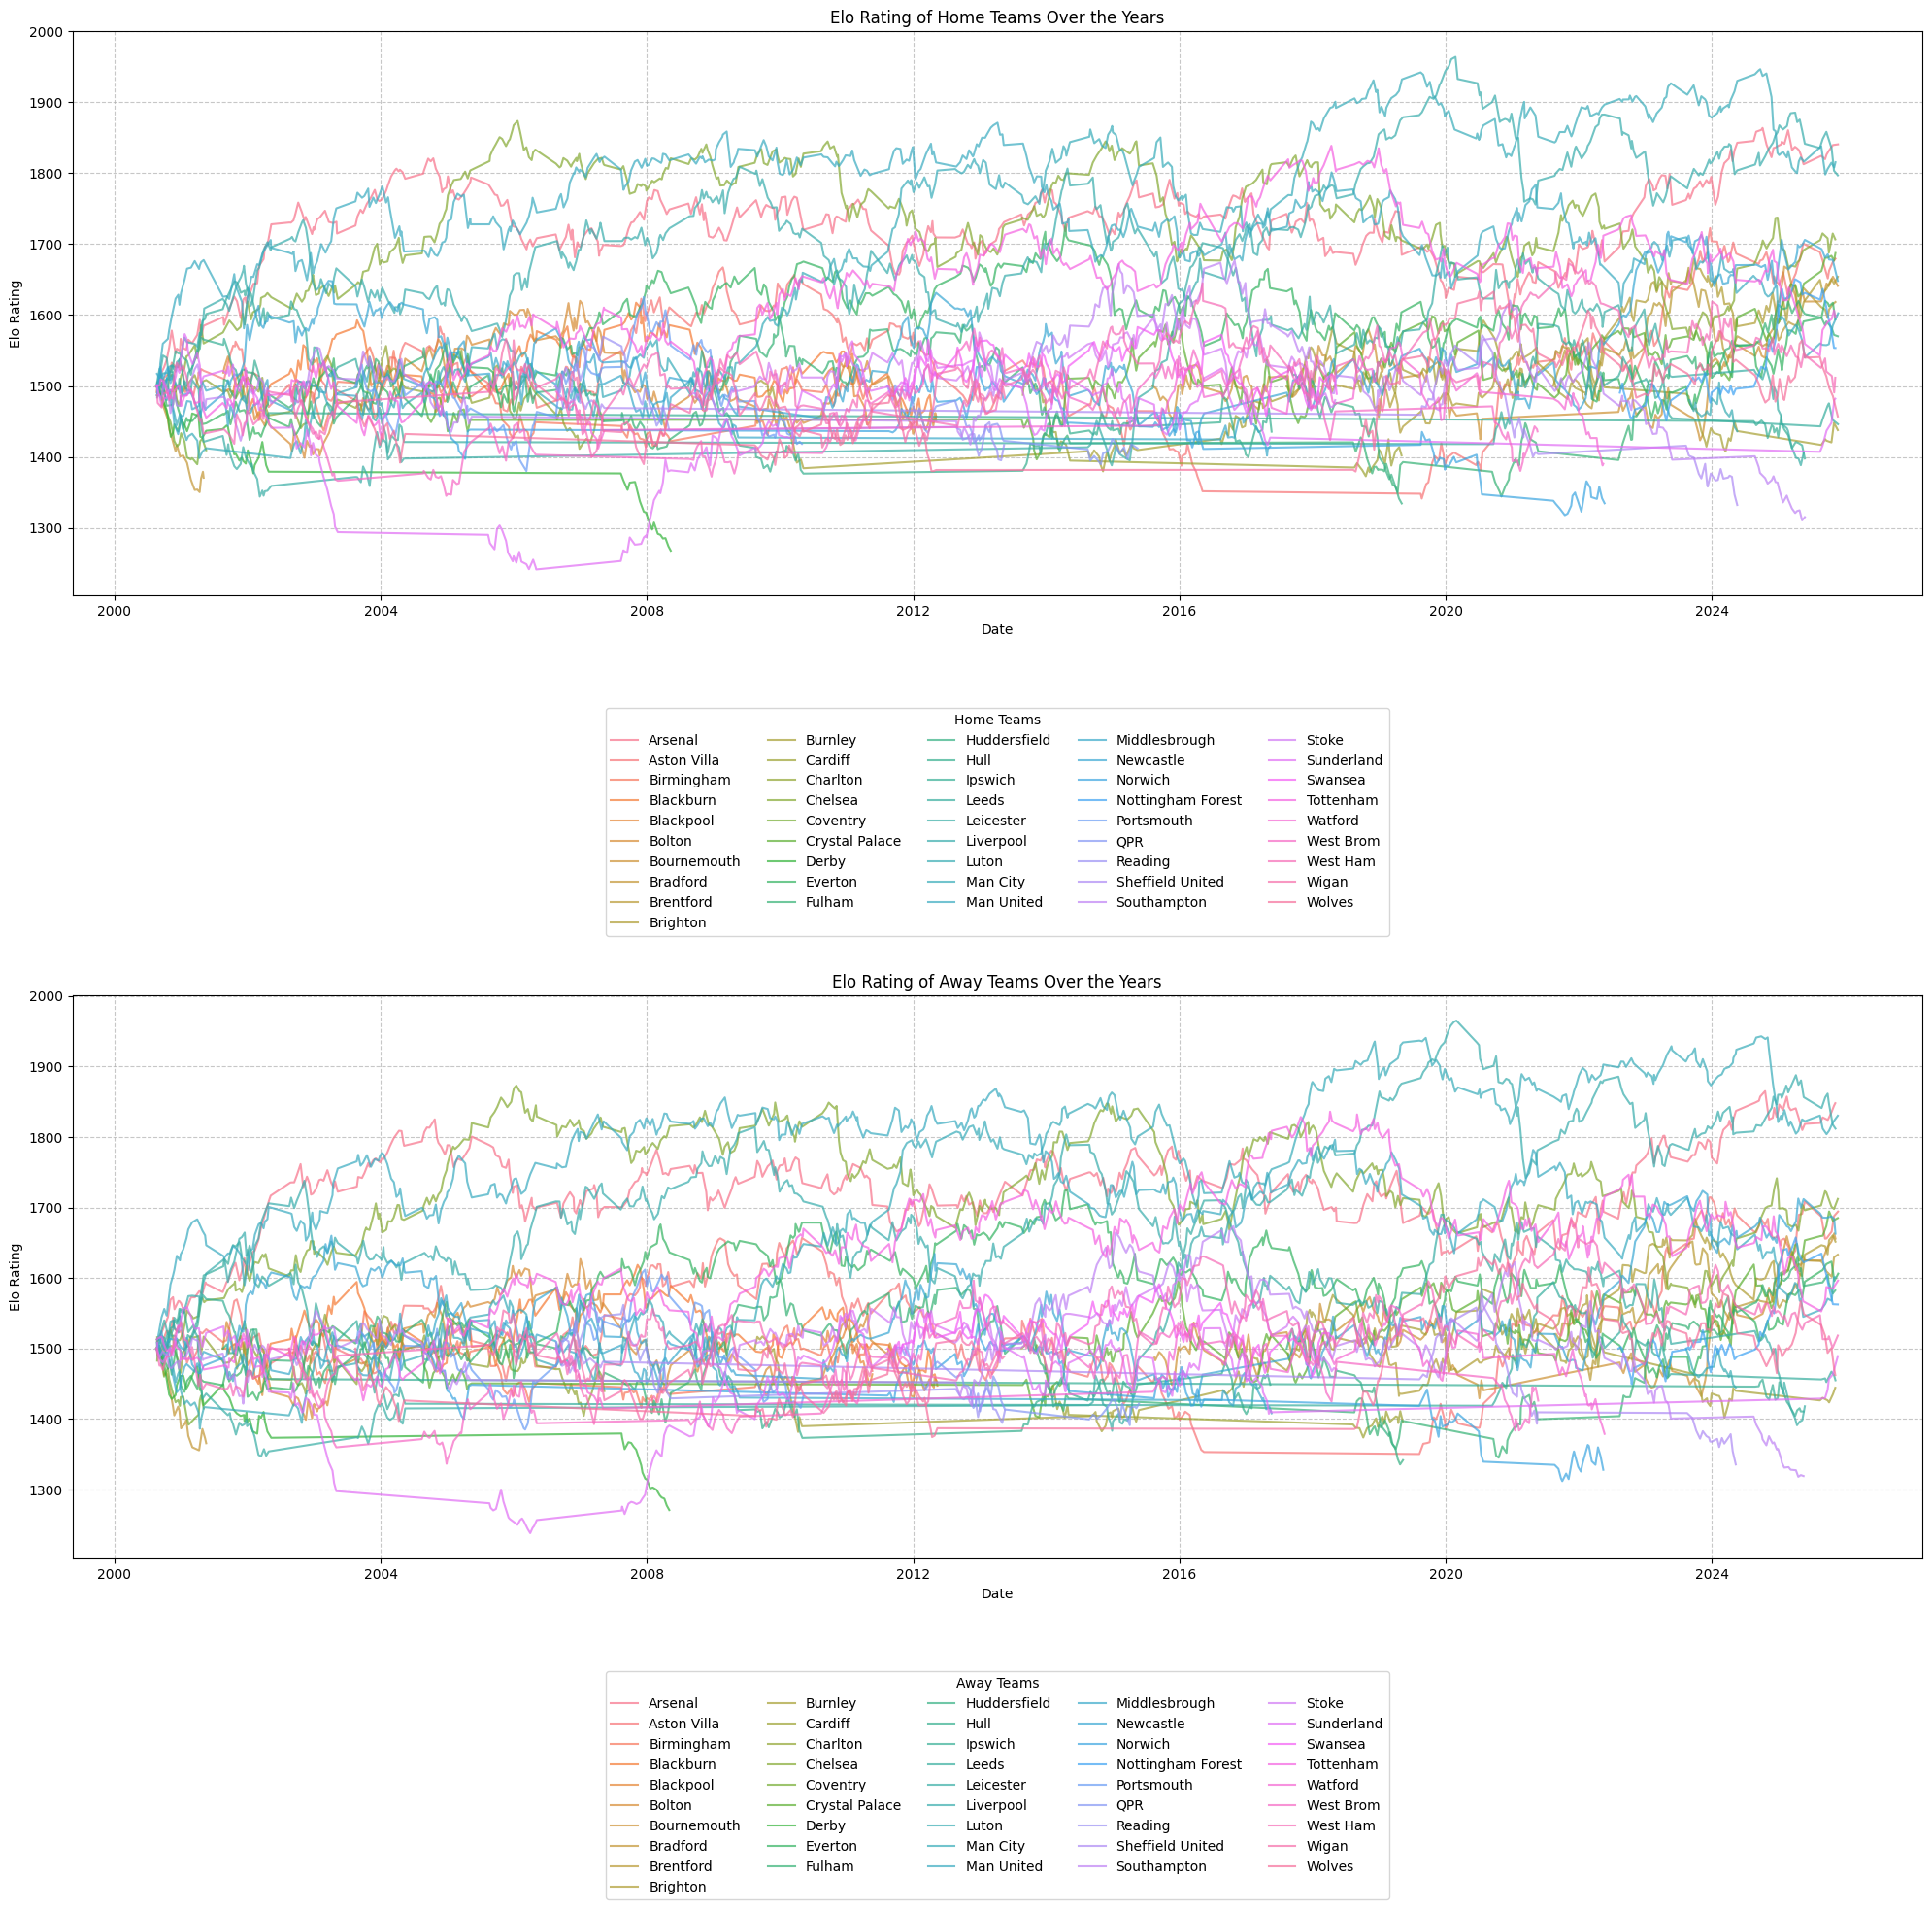

In [48]:
# Create a DataFrame for Elo ratings over time from the matches_with_elo DataFrame
home_elo_history = matches_with_elo[['Date', 'HomeTeam', 'home_elo_pre']].copy()
home_elo_history.rename(columns={'HomeTeam': 'Team', 'home_elo_pre': 'Elo Rating'}, inplace=True)

away_elo_history = matches_with_elo[['Date', 'AwayTeam', 'away_elo_pre']].copy()
away_elo_history.rename(columns={'AwayTeam': 'Team', 'away_elo_pre': 'Elo Rating'}, inplace=True)

# Get all unique teams and sort them alphabetically for consistent legend order
all_unique_teams = sorted(pd.concat([home_elo_history['Team'], away_elo_history['Team']]).unique())

# Plotting the Elo ratings over time for home teams and away teams separately
plt.figure(figsize=(20, 20)) # Adjusted figure size for vertical stacking

plt.subplot(2, 1, 1) # 2 rows, 1 column, first plot
sns.lineplot(data=home_elo_history, x='Date', y='Elo Rating', hue='Team', hue_order=all_unique_teams, alpha=0.7)
plt.title('Elo Rating of Home Teams Over the Years')
plt.xlabel('Date')
plt.ylabel('Elo Rating')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(0.5, -0.2), loc='upper center', borderaxespad=0., ncol=5, title='Home Teams')

plt.subplot(2, 1, 2) # 2 rows, 1 column, second plot
sns.lineplot(data=away_elo_history, x='Date', y='Elo Rating', hue='Team', hue_order=all_unique_teams, alpha=0.7)
plt.title('Elo Rating of Away Teams Over the Years')
plt.xlabel('Date')
plt.ylabel('Elo Rating')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(0.5, -0.2), loc='upper center', borderaxespad=0., ncol=5, title='Away Teams')

plt.tight_layout()
plt.show()

### Visualising Distributions of Elo Features

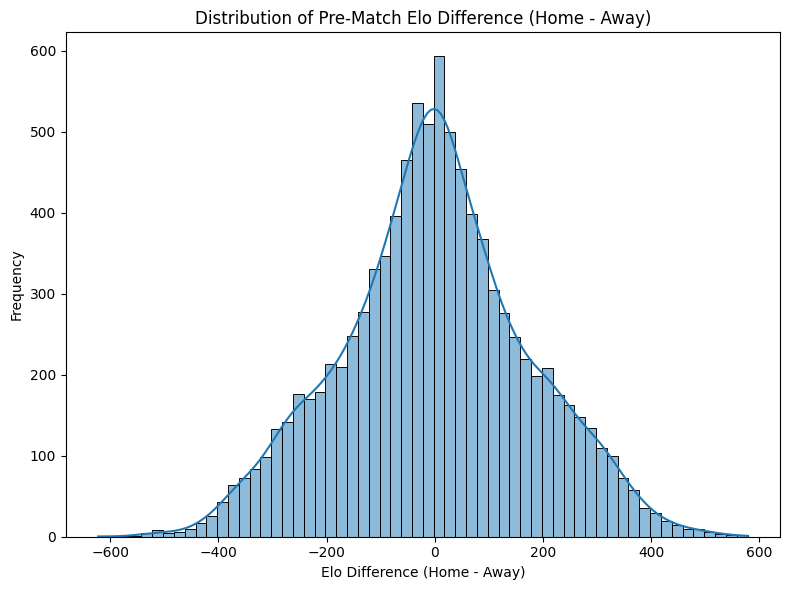

In [49]:
plt.figure(figsize=(8, 6))
sns.histplot(matches_with_elo['elo_diff_pre'], kde=True)
plt.title('Distribution of Pre-Match Elo Difference (Home - Away)')
plt.xlabel('Elo Difference (Home - Away)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Correlation of Elo Features with FTR


Correlation of Elo Features with FTR_encoded:


,FTR_encoded
FTR_encoded,1.000000
away_elo_pre,0.286300
home_elo_pre,-0.275132
elo_diff_pre,-0.397908


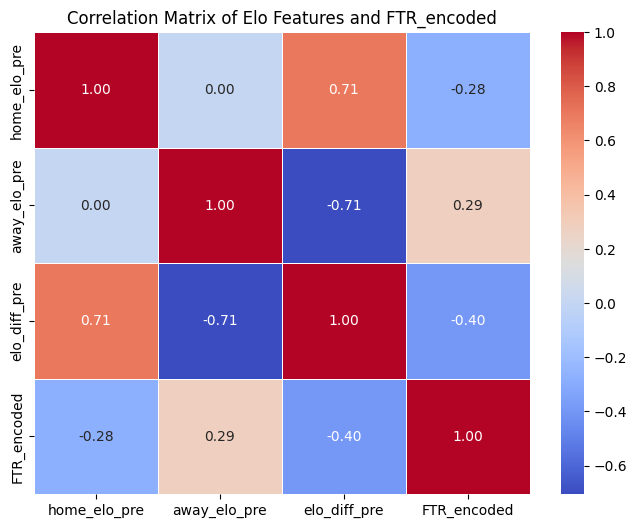

In [50]:
print("\nCorrelation of Elo Features with FTR_encoded:")
elo_features_for_corr = ['home_elo_pre', 'away_elo_pre', 'elo_diff_pre']
correlation_df_elo = matches_with_elo[elo_features_for_corr + ['FTR_encoded']]

correlation_matrix_elo = correlation_df_elo.corr()
display(correlation_matrix_elo['FTR_encoded'].sort_values(ascending=False))

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_elo, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Elo Features and FTR_encoded')
plt.show()

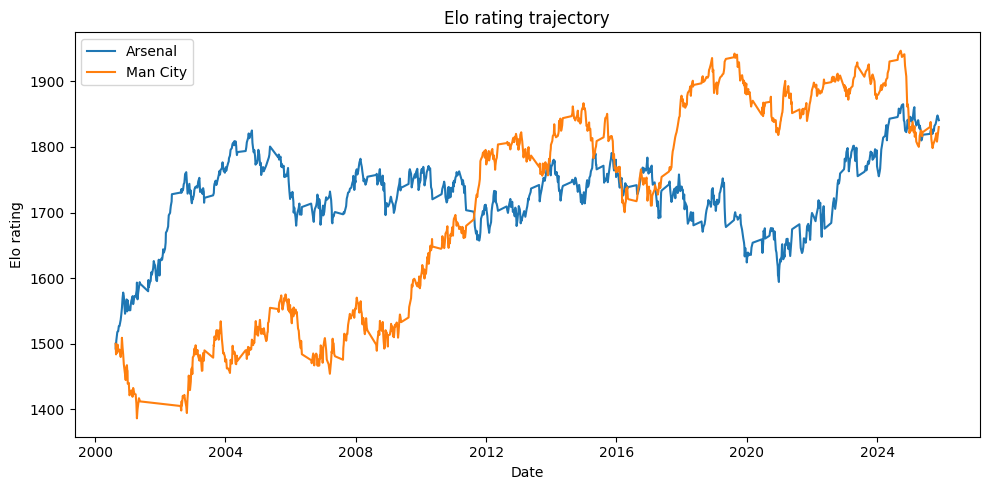

In [51]:
example_teams = ["Arsenal", "Man City"]  # adjust to match names

# Create a DataFrame for Elo ratings over time from the matches_with_elo DataFrame
home_elo_history = matches_with_elo[['Date', 'HomeTeam', 'home_elo_pre']].copy()
home_elo_history.rename(columns={'HomeTeam': 'Team', 'home_elo_pre': 'Rating'}, inplace=True)

away_elo_history = matches_with_elo[['Date', 'AwayTeam', 'away_elo_pre']].copy()
away_elo_history.rename(columns={'AwayTeam': 'Team', 'away_elo_pre': 'Rating'}, inplace=True)

# Combine home and away Elo histories
elo_long = pd.concat([home_elo_history, away_elo_history], ignore_index=True)
elo_long = elo_long.sort_values(by=['Team', 'Date']).reset_index(drop=True)

plt.figure(figsize=(10,5))
for team in example_teams:
    subset = elo_long[elo_long["Team"] == team]
    plt.plot(subset["Date"], subset["Rating"], label=team)
plt.title("Elo rating trajectory")
plt.xlabel("Date")
plt.ylabel("Elo rating")
plt.legend()
plt.tight_layout()
plt.show()

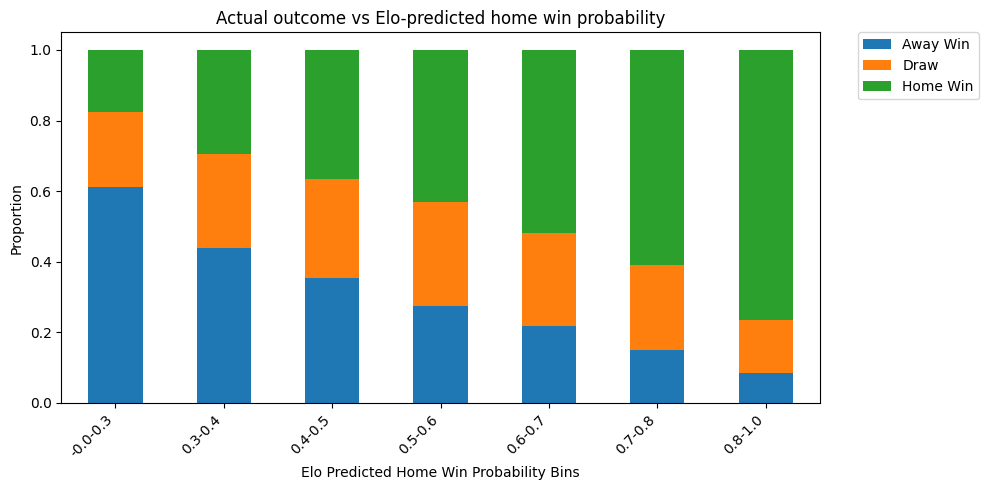

In [81]:
def elo_prob(home_elo, away_elo, home_adv=50.0):
    diff = (home_elo + home_adv) - away_elo
    return 1.0 / (1.0 + 10 ** (-diff / 400))

# Calculate the Elo-predicted home win probability for each match
matches_with_elo["elo_home_win_prob"] = elo_prob(
    matches_with_elo["home_elo_pre"],
    matches_with_elo["away_elo_pre"],
)

# Define bins for the Elo home win probabilities
bins = [0.0, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]
matches_with_elo["elo_bin"] = pd.cut(
    matches_with_elo["elo_home_win_prob"], bins=bins, include_lowest=True
)

# Map FTR_encoded to human-readable labels for the plot
FTR_labels = {0: 'Home Win', 1: 'Draw', 2: 'Away Win'}
matches_with_elo['FTR_label'] = matches_with_elo['FTR_encoded'].map(FTR_labels)

# Calculate the proportion of actual outcomes within each Elo probability bin
stack = (
    matches_with_elo
    .groupby(["elo_bin", "FTR_label"], observed=False) # 'observed=False' to suppress FutureWarning for categorical groupby
    .size()
    .groupby(level=0, observed=False) # add observed=False here as well
    .apply(lambda s: s / s.sum())
    .unstack(fill_value=0)
)

# Plot the stacked bar chart
ax = stack.plot(kind="bar", stacked=True, figsize=(10,5))
plt.ylabel("Proportion")
plt.title("Actual outcome vs Elo-predicted home win probability")
plt.xlabel("Elo Predicted Home Win Probability Bins") # More descriptive x-axis label

# Format x-axis ticks to show bin ranges clearly
x_ticks = []
for interval_tuple in stack.index:
    # Assuming the Interval object is the first element if the index is a MultiIndex producing tuples
    if isinstance(interval_tuple, tuple):
        interval = interval_tuple[0]
    else:
        interval = interval_tuple
    x_ticks.append(f'{interval.left:.1f}-{interval.right:.1f}')
plt.xticks(ticks=range(len(x_ticks)), labels=x_ticks, rotation=45, ha='right')

# Move the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

## Head-to-Head (H2H)

This section describes the `compute_h2h` and `compute_h2h_goal_diff` functions, which together calculate head-to-head scores between two teams based on their past encounters. The `compute_h2h score` aims to quantify which team historically has a better record against the other, with a score greater than 0.5 favouring the current home team. The `compute_h2h_goal_diff` quantifies the historical goal difference between teams, indicating whether the home team has historically outscored the away team, or vice versa, in their past encounters.

### `get_past_matches` Function
This helper function retrieves all previous matches between the specified home and away teams that occurred strictly before the given date. It considers matches where either team was at home or away.

In [53]:
# Find all past games between two teams (strictly before Date)
def get_past_matches(df: pd.DataFrame, home: str, away: str, date: pd.Timestamp):
    mask = (
        (
            ((df["HomeTeam"] == home) & (df["AwayTeam"] == away)) |
            ((df["HomeTeam"] == away) & (df["AwayTeam"] == home))
        )
        & (df["Date"] < date)   # past matches only
    )
    return df.loc[mask]

### `compute_h2h` Function
The `compute_h2h` function calculates a weighted H2H score, incorporating several factors:

- **Time Decay (k)**: Older games contribute less to the H2H score. The weight `w` for each past match is calculated using an exponential decay function: `w = exp(-k * age_days)`, where `age_days` is the number of days since the past match. A smaller `k` means a slower decay (older games remain more relevant).

- **Away-Side Weight Factor (`j`)**: When the current home team played away in a past match against the current away team, their performance in that away game is weighted by `j`. This allows for adjusting the importance of away performances.

- **Bonus for Drawing Away (`l`)**: If the current home team played away in a past match and secured a draw, an additional bonus l is added to their score for that match. This reflects the tactical advantage of drawing away from home.

#### Calculation Steps

1. **Retrieve Past Matches**: Uses `get_past_matches` to find all historical encounters between the two teams before the current match date.

2. **Handle No Past Matches**: If no past matches are found, a neutral score of 0.5 is returned.

3. **Iterate and Calculate Weighted Score**: For each past match:
   - Compute `age_days` and the time-decay weight `w`.
   - Determine the `result` from the viewpoint of the *current* `HomeTeam` (Win = 1.0, Draw = 0.5, Loss = 0.0).
   - If the *current* `HomeTeam` was also the `HomeTeam` in the past match:  
     - Score contribution = `result * w`
   - If the *current* `HomeTeam` was the `AwayTeam` in the past match:  
     - Score contribution = `result * w * j`  
     - If it was a Draw, add an additional bonus `l`.
   - Accumulate:  
     - `weighted_sum += contribution`  
     - `weight_total += w`

4. **Final H2H Score**: The H2H score is computed as `weighted_sum / weight_total`. If `weight_total` is 0 (e.g., if `k` is too large and all weights become negligible), the score defaults to 0.5.

In [54]:
# # Compute H2H score for one specific match (HomeTeam vs AwayTeam at Date)
# def compute_h2h(
#     df: pd.DataFrame,
#     home: str,
#     away: str,
#     date: pd.Timestamp,
#     k: float = 0.001,   # time-decay
#     j: float = 0.8,     # away-side weight factor
#     l: float = 0.1      # bonus for drawing away
# ) -> float:
#     """
#     Returns a H2H score in [0,1] from the *home team's* perspective:
#       - >0.5 => historically favours current home team
#       - <0.5 => historically favours current away team
#     """
#     matches = get_past_matches(df, home, away, date)

#     # Default neutral value if they’ve never met
#     if matches.empty:
#         return 0.5

#     weighted_sum = 0.0
#     weight_total = 0.0

#     for _, row in matches.iterrows():
#         # How old is this past match, in days?
#         age_days = (date - row["Date"]).days
#         w = np.exp(-k * age_days)  # older games → smaller weight

#         # 1 point for win, 0.5 for draw, 0 for loss (from *current HomeTeam* perspective)
#         if row["HomeTeam"] == home:
#             # Current HomeTeam was also home in this past match
#             if row["FTR"] == "H":      # home won
#                 result = 1.0
#             elif row["FTR"] == "D":    # draw
#                 result = 0.5
#             else:                      # "A" → home lost
#                 result = 0.0

#             weighted_sum += result * w
#             weight_total += w

#         else:
#             # Current HomeTeam was AWAY in this past match
#             # j: extra weight for away performances
#             # l: extra bonus for away draws
#             if row["FTR"] == "A":      # away team (current home) won
#                 result = 1.0
#             elif row["FTR"] == "D":    # away draw
#                 result = 0.5 + l
#             else:                      # "H" → away (current home) lost
#                 result = 0.0

#             weighted_sum += result * w * j
#             weight_total += w * j

#     return weighted_sum / weight_total if weight_total > 0 else 0.5

### `compute_h2h_goal_diff` Function

The `compute_h2h_goal_diff` function quantifies the historical goal difference between two teams, taking into account several factors to provide a weighted head-to-head score from the current home team's perspective. This score indicates whether the home team has historically outscored the away team, or vice versa, in their past encounters.

-   **Time Decay (k)**: Similar to the `compute_h2h` function, older games contribute less to the overall goal difference score. The weight `w` for each past match is calculated using an exponential decay function: `w = exp(-k * age_days)`, where `age_days` is the number of days since the past match. A smaller `k` means a slower decay, so older games retain more relevance.

-   **Away-Side Weight Factor (j)**: When the current home team played away in a past match against the current away team, their goal difference performance in that away game is weighted by `j`. This allows for adjusting the importance of away performances when considering historical goal differences.

#### Calculation Steps

1.  **Retrieve Past Matches**: The function first uses `get_past_matches` to find all historical encounters between the two teams that occurred strictly before the current match date.

2.  **Handle No Past Matches**: If no past matches are found, a neutral goal difference of 0.0 is returned.

3.  **Iterate and Calculate Weighted Goal Difference**: For each past match:
    -   The `age_days` and the time-decay weight `w` are computed.
    -   The goal difference (`gd`) is calculated from the perspective of the *current* `HomeTeam`:
        -   If the *current* `HomeTeam` was also the `HomeTeam` in the past match, `gd` is `FTHG - FTAG`.
        -   If the *current* `HomeTeam` was the `AwayTeam` in the past match, `gd` is `FTAG - FTHG` (goals scored by the current home team as away team minus goals conceded).
    -   The effective weight for the match is `w` if the current home team played at home in the past match, and `w * j` if they played away.
    -   The `weighted_sum` and `weight_total` are accumulated using `gd` and the effective weight.

4.  **Final H2H Goal Difference**: The H2H goal difference score is computed as `weighted_sum / weight_total`. If `weight_total` is 0 (e.g., if `k` is too large and all weights become negligible, or if no matches were weighted), the score defaults to 0.0.

In [55]:
# # Compute H2H based on goal difference
# def compute_h2h_goal_diff(
#     df: pd.DataFrame,
#     home: str,
#     away: str,
#     date: pd.Timestamp,
#     k: float = 0.001,   # time-decay
#     j: float = 0.8,     # away-side weight factor
# ) -> float:
#     """
#     Goal-difference-based H2H (can be positive or negative),
#     from the *current home team's* perspective:

#       > 0  => home team has historically outscored the away team
#       < 0  => away team has historically outscored the home team
#       ~= 0 => fairly balanced

#     Uses time-decayed, weighted average goal difference.
#     """
#     matches = get_past_matches(df, home, away, date)

#     if matches.empty:
#         return 0.0  # neutral goal-diff H2H if no history

#     weighted_sum = 0.0
#     weight_total = 0.0

#     for _, row in matches.iterrows():
#         age_days = (date - row["Date"]).days
#         w = np.exp(-k * age_days)

#         if row["HomeTeam"] == home:
#             # Current home was home in this past match
#             gd = row["FTHG"] - row["FTAG"]
#             weighted_sum += gd * w
#             weight_total += w
#         else:
#             # Current home was AWAY in this past match
#             # From current home's perspective, goal diff is away goals - home goals
#             gd = row["FTAG"] - row["FTHG"]
#             weighted_sum += gd * w * j
#             weight_total += w * j

#     return weighted_sum / weight_total if weight_total > 0 else 0.0


### Putting it all Together

1.  **Initialisation**: Two empty lists, `h2h_result_values` and `h2h_gd_values`, are created to temporarily store the calculated H2H scores for each match.

2.  **Iterating Through Matches**: The code loops through every match (row) in your `train_df`.

3.  **Calculating H2H Scores**: For each match:
    *   It calls the `compute_h2h` function to get a result-based H2H score (`h2h_res`). This function assesses the historical win/loss/draw record between the two teams, from the current home team's perspective, applying time decay to give more weight to recent matches, and adjusting for away-side performance and draws.
    *   It then calls the `compute_h2h_goal_diff` function to get a goal-difference-based H2H score (`h2h_gd`). This function calculates a weighted average of the historical goal differences between the teams, also from the home team's viewpoint and incorporating time decay and away-side weighting.

4.  **Appending Results**: The calculated `h2h_res` and `h2h_gd` for the current match are added to their respective lists.

5.  **Creating Enriched DataFrame**: After processing all matches, a copy of the original `train_df` is made, named `matches_with_h2h`.

6.  **Adding New Features**: The accumulated `h2h_result_values` and `h2h_gd_values` are then added as new columns, `h2h_score` and `h2h_goal_diff`, to the `matches_with_h2h` DataFrame. These new columns provide valuable insights into the historical performance dynamics between competing teams, enhancing the dataset for predictive modeling.

In [56]:
# # Apply both H2H features to training matches
# h2h_result_values = []
# h2h_gd_values = []

# for _, row in train_df.iterrows():
#     h2h_res = compute_h2h(
#         df=train_df,
#         home=row["HomeTeam"],
#         away=row["AwayTeam"],
#         date=row["Date"],
#         k=0.001,
#         j=0.8,
#         l=0.1,
#     )
#     h2h_gd = compute_h2h_goal_diff(
#         df=train_df,
#         home=row["HomeTeam"],
#         away=row["AwayTeam"],
#         date=row["Date"],
#         k=0.001,
#         j=0.8,
#     )

#     h2h_result_values.append(h2h_res)
#     h2h_gd_values.append(h2h_gd)

# matches_with_h2h = train_df.copy()
# matches_with_h2h["h2h_score"] = h2h_result_values        # result-based (0–1)
# matches_with_h2h["h2h_goal_diff"] = h2h_gd_values        # goal-diff-based (±)
# matches_with_h2h

### Visualising Distributions of H2H Features

In [57]:
# plt.figure(figsize=(12, 5))

# # Result-based H2H score
# plt.subplot(1, 2, 1)
# sns.histplot(matches_with_h2h["h2h_score"], kde=True)
# plt.title("Distribution of H2H Result Score")
# plt.xlabel("H2H Score (Home Team Perspective)")
# plt.ylabel("Frequency")
# plt.axvline(0.5, color="red", linestyle="--", label="Neutral (0.5)")
# plt.legend()

# # Goal-difference-based H2H
# plt.subplot(1, 2, 2)
# sns.histplot(matches_with_h2h["h2h_goal_diff"], kde=True)
# plt.title("Distribution of H2H Goal Difference")
# plt.xlabel("Time-decayed H2H Goal Difference (Home Team Perspective)")
# plt.ylabel("Frequency")
# plt.axvline(0.0, color="red", linestyle="--", label="Neutral (0)")
# plt.legend()

# plt.tight_layout()
# plt.show()

### Correlation of H2H Features with FTR

In [58]:
# print("\nCorrelation of H2H features with FTR_encoded:")

# # Include both H2H features
# correlation_df_h2h = matches_with_h2h[["h2h_score", "h2h_goal_diff", "FTR_encoded"]]

# correlation_matrix_h2h = correlation_df_h2h.corr()

# # Show correlations with the target
# display(correlation_matrix_h2h["FTR_encoded"].sort_values(ascending=False))

# plt.figure(figsize=(8, 6))
# sns.heatmap(
#     correlation_matrix_h2h,
#     annot=True,
#     cmap="coolwarm",
#     fmt=".2f",
#     linewidths=.5
# )
# plt.title("Correlation Matrix of H2H Features and FTR_encoded")
# plt.show()


### Test

#### Calculation Steps

1. **Retrieve Past Matches**  
   All historical encounters between the two teams prior to the current match date are collected using `get_past_matches`.

2. **Handle No Past Matches**  
   If no previous meetings exist, four neutral values are returned:  
   - H2H Home-as-Home score: `0.5`  
   - H2H Home-as-Away score: `0.5`  
   - H2H Home-as-Home goal-difference score: `0.0`  
   - H2H Home-as-Away goal-difference score: `0.0`

3. **Iterate Through Past Matches with Time Decay**  
   For each past match:
   - Compute how old the match is in days, then calculate a time-decay weight `w`: older matches receive lower weight.
   - Determine the outcome from the viewpoint of the current HomeTeam:  
     - Win → `1.0`  
     - Draw → `0.5`  
     - Loss → `0.0`
   - Compute the goal difference from the HomeTeam's viewpoint:  
     - If the current home team was the home team in that past match: use `FTHG - FTAG`.  
     - If it was the away team: use `FTAG - FTHG`.

   The contributions are split into two independent contexts:

   **a) Home-as-Home (HAH)**  
   When the current HomeTeam was also the home side in the past match:  
   - Add `result * w` to the HAH score sum  
   - Add `gd * w` to the HAH goal-difference sum  
   - Add `w` to the HAH weight total  

   **b) Home-as-Away (HAA)**  
   When the current HomeTeam was the away side in the past match:  
   - Add `result * w` to the HAA score sum  
   - Add `gd * w` to the HAA goal-difference sum  
   - Add `w` to the HAA weight total  

4. **Final Scores**  
   After processing all past matches, four values are produced:

   - H2H score (Home-as-Home)  
   - H2H goal-difference score (Home-as-Home)  
   - H2H score (Home-as-Away)  
   - H2H goal-difference score (Home-as-Away)

   Each value is computed by dividing the corresponding weighted sum by its total weight.  
   If a context has no valid matches (its weight total equals zero), neutral default values are returned instead (`0.5` for the H2H score and `0.0` for the goal-difference score).

This design produces two separate historical performance indicators, depending on whether the current HomeTeam was previously playing at home or away, ensuring the model captures asymmetric patterns in the rivalry.


In [59]:
# Compute H2H score for one specific match (HomeTeam vs AwayTeam at Date)
def compute_h2h(
    df: pd.DataFrame,
    home: str,
    away: str,
    date: pd.Timestamp,
    k: float = 0.001,   # time-decay
) -> float:
    """
    Returns 4 values:
    I. H2H score in [0,1] from the *home team's* perspective:
      - >0.5 => historically favours current home team
      - <0.5 => historically favours current away team
      Split into two cases:
      1. Home-as-Home: considers only games where current home team was home team
      2. Home-as-Away: considers only games where current home team was away team

    II. H2H goal difference from the *home team's* perspective:
      - >0 => historically favours current home team
      - <0 => historically favours current away team
      Split into two cases:
      3. Home-as-Home
      4. Home-as-Away

    """
    matches = get_past_matches(df, home, away, date)

    # Default neutral value if they’ve never met
    if matches.empty:
        return 0.5, 0.5, 0, 0

    weighted_sum_hah = 0.0
    weighted_sum_haa = 0.0
    weighted_sum_gd_hah = 0.0
    weighted_sum_gd_haa = 0.0
    weight_total_hah = 0.0
    weight_total_haa = 0.0

    for _, row in matches.iterrows():
        # How old is this past match, in days?
        age_days = (date - row["Date"]).days
        w = np.exp(-k * age_days)  # older games → smaller weight

        # 1 point for win, 0.5 for draw, 0 for loss (from *current HomeTeam* perspective)
        # Simple goal difference: Goals for the current home team - Goals for the current away team
        if row["HomeTeam"] == home:
            # Current HomeTeam was also home in this past match

            # H2H score:
            if row["FTR"] == "H":      # home won
                result = 1.0
            elif row["FTR"] == "D":    # draw
                result = 0.5
            else:                      # home lost
                result = 0.0
            weighted_sum_hah += result * w

            # H2H goal difference
            result_gd = row["FTHG"] - row["FTAG"]
            weighted_sum_gd_hah += result_gd * w

            weight_total_hah += w


        else:
            # Current HomeTeam was AWAY in this past match

            # H2H score:
            if row["FTR"] == "A":      # away team (current home) won
                result = 1.0
            elif row["FTR"] == "D":    # away draw
                result = 0.5
            else:                      # away (current home) lost
                result = 0.0
            weighted_sum_haa += result * w

            # H2H goal difference
            result_gd = row["FTAG"] - row["FTHG"]
            weighted_sum_gd_haa += result_gd * w

            weight_total_haa += w


    h2h_hah = weighted_sum_hah / weight_total_hah if weight_total_hah > 0 else 0.5
    h2h_gd_hah = weighted_sum_gd_hah / weight_total_hah if weight_total_hah > 0 else 0.0

    h2h_haa = weighted_sum_haa / weight_total_haa if weight_total_haa > 0 else 0.5
    h2h_gd_haa = weighted_sum_gd_haa / weight_total_haa if weight_total_haa > 0 else 0.0

    return h2h_hah, h2h_haa, h2h_gd_hah, h2h_gd_haa


h2h_values_hah = []
h2h_gd_values_hah = []
h2h_values_haa = []
h2h_gd_values_haa = []
for _, row in train_df.iterrows():
    h2h_hah, h2h_haa, h2h_gd_hah, h2h_gd_haa = compute_h2h(
        df=train_df,
        home=row["HomeTeam"],
        away=row["AwayTeam"],
        date=row["Date"],
        k=0.001,
    )
    h2h_values_hah.append(h2h_hah)
    h2h_gd_values_hah.append(h2h_gd_hah)
    h2h_values_haa.append(h2h_haa)
    h2h_gd_values_haa.append(h2h_gd_haa)

matches_with_h2h = train_df.copy()
matches_with_h2h["h2h_score_hah"] = h2h_values_hah
matches_with_h2h["h2h_score_haa"] = h2h_values_haa
matches_with_h2h["h2h_gd_score_hah"] = h2h_gd_values_hah
matches_with_h2h["h2h_gd_score_haa"] = h2h_gd_values_haa
matches_with_h2h

,Date,Season,HomeTeam,AwayTeam,FTR_encoded,FTHG,FTAG,FTR,HTHG,HTAG,...,HF,AF,HY,AY,HR,AR,h2h_score_hah,h2h_score_haa,h2h_gd_score_hah,h2h_gd_score_haa
0,2000-08-19,2000,Charlton,Man City,0,4.0,0.0,H,2.0,0.0,...,13.0,12.0,1.0,2.0,0.0,0.0,0.500000,0.500000,0.000000,0.000000
1,2000-08-19,2000,Chelsea,West Ham,0,4.0,2.0,H,1.0,0.0,...,19.0,14.0,1.0,2.0,0.0,0.0,0.500000,0.500000,0.000000,0.000000
2,2000-08-19,2000,Coventry,Middlesbrough,2,1.0,3.0,A,1.0,1.0,...,15.0,21.0,5.0,3.0,1.0,0.0,0.500000,0.500000,0.000000,0.000000
3,2000-08-19,2000,Derby,Southampton,1,2.0,2.0,D,1.0,2.0,...,11.0,13.0,1.0,1.0,0.0,0.0,0.500000,0.500000,0.000000,0.000000
4,2000-08-19,2000,Leeds,Everton,0,2.0,0.0,H,2.0,0.0,...,21.0,20.0,1.0,3.0,0.0,0.0,0.500000,0.500000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9615,2025-11-22,2025,Brighton,Brentford,0,2.0,1.0,H,0.0,1.0,...,10.0,9.0,4.0,2.0,0.0,0.0,0.699216,0.259410,0.529755,-1.076457
9616,2025-11-22,2025,Newcastle,Man City,0,2.0,1.0,H,0.0,0.0,...,13.0,8.0,1.0,3.0,0.0,0.0,0.285218,0.000353,-0.771871,-3.024252
9617,2025-11-23,2025,Arsenal,Tottenham,0,4.0,1.0,H,2.0,0.0,...,11.0,15.0,1.0,3.0,0.0,0.0,0.856671,0.677564,1.026521,0.188672
9618,2025-11-23,2025,Leeds,Aston Villa,2,1.0,2.0,A,1.0,0.0,...,18.0,16.0,5.0,1.0,0.0,0.0,0.211174,0.371230,-1.262532,0.153158


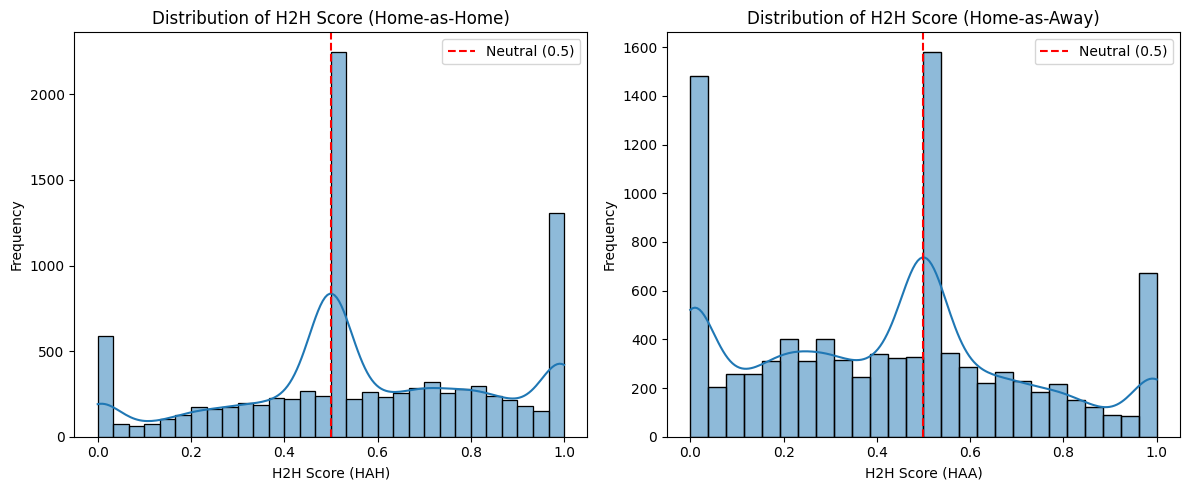

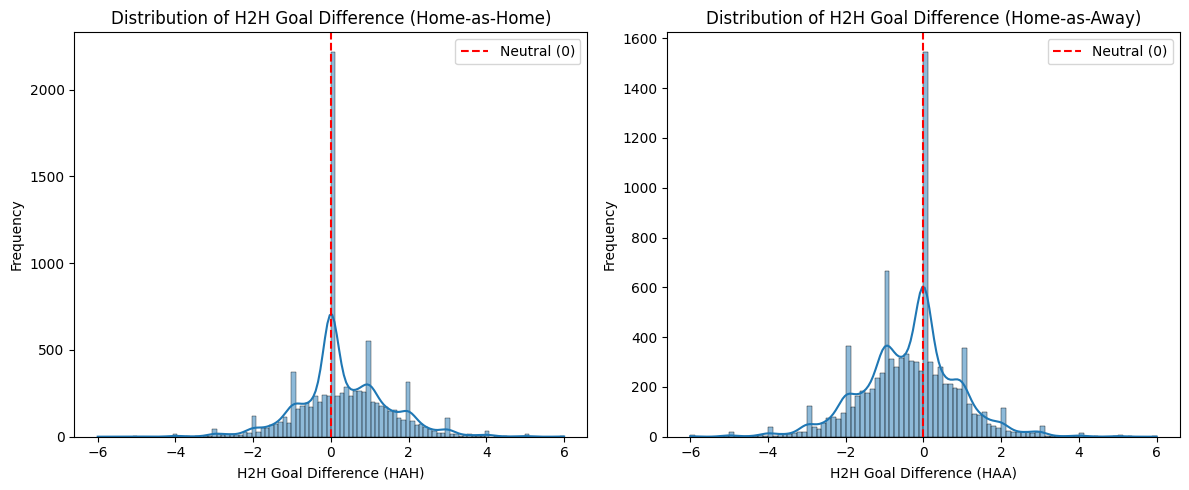

In [60]:
# ==========================================================
# Combined Distribution of H2H Scores
# ==========================================================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # First subplot for H2H Score (HAH)
sns.histplot(matches_with_h2h['h2h_score_hah'], kde=True)
plt.title('Distribution of H2H Score (Home-as-Home)')
plt.xlabel('H2H Score (HAH)')
plt.ylabel('Frequency')
plt.axvline(0.5, color="red", linestyle="--", label="Neutral (0.5)")
plt.legend()

plt.subplot(1, 2, 2) # Second subplot for H2H Score (HAA)
sns.histplot(matches_with_h2h['h2h_score_haa'], kde=True)
plt.title('Distribution of H2H Score (Home-as-Away)')
plt.xlabel('H2H Score (HAA)')
plt.ylabel('Frequency')
plt.axvline(0.5, color="red", linestyle="--", label="Neutral (0.5)")
plt.legend()

plt.tight_layout()
plt.show()

# ==========================================================
# Combined Distribution of H2H Goal Differences
# ==========================================================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # First subplot for H2H Goal Difference (HAH)
sns.histplot(matches_with_h2h['h2h_gd_score_hah'], kde=True)
plt.title('Distribution of H2H Goal Difference (Home-as-Home)')
plt.xlabel('H2H Goal Difference (HAH)')
plt.ylabel('Frequency')
plt.axvline(0.0, color="red", linestyle="--", label="Neutral (0)")
plt.legend()

plt.subplot(1, 2, 2) # Second subplot for H2H Goal Difference (HAA)
sns.histplot(matches_with_h2h['h2h_gd_score_haa'], kde=True)
plt.title('Distribution of H2H Goal Difference (Home-as-Away)')
plt.xlabel('H2H Goal Difference (HAA)')
plt.ylabel('Frequency')
plt.axvline(0.0, color="red", linestyle="--", label="Neutral (0)")
plt.legend()

plt.tight_layout()
plt.show()


Correlation of all H2H Features with FTR_encoded:


,FTR_encoded
FTR_encoded,1.000000
h2h_score_hah,-0.188759
h2h_score_haa,-0.199502
h2h_gd_score_hah,-0.213115
h2h_gd_score_haa,-0.233713


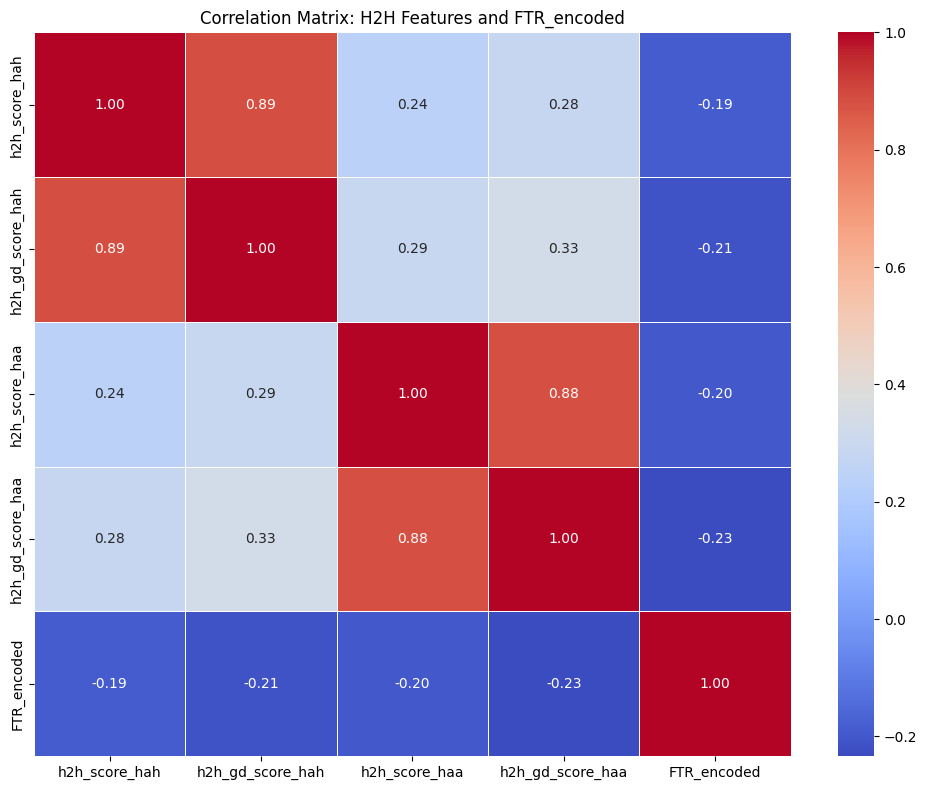

In [61]:
# ============================================
# Correlation of H2H Features with FTR_encoded
# ============================================

print("\nCorrelation of all H2H Features with FTR_encoded:")

# Select the four new H2H features + target
h2h_corr_df = matches_with_h2h[
    ['h2h_score_hah', 'h2h_gd_score_hah',
     'h2h_score_haa', 'h2h_gd_score_haa',
     'FTR_encoded']
]

# Compute correlation matrix
h2h_corr_matrix = h2h_corr_df.corr()

# Display correlations with the target, sorted
display(h2h_corr_matrix['FTR_encoded'].sort_values(ascending=False))

# Heatmap of the full correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(h2h_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix: H2H Features and FTR_encoded')
plt.tight_layout()
plt.show()


## Build Features

### Combine EWM, Elo, H2H Features into a Single Dataframe

In [62]:
# Start with a copy of train_df to retain original columns including FTR and raw stats
modelling_df = train_df.copy()

# Ensure chronological order
modelling_df = modelling_df.sort_values("Date").reset_index(drop=True)

# Define common merge keys (Date, Season, HomeTeam, AwayTeam)
# These columns are present in all feature-engineered dataframes and train_df
common_merge_keys = ["Date", "Season", "HomeTeam", "AwayTeam"]

# Merge matches_with_form (rolling averages)
# Get only the new feature columns from matches_with_form, explicitly excluding FTR_encoded
form_feature_cols = [col for col in matches_with_form.columns if col not in common_merge_keys and col != "FTR_encoded"]
modelling_df = modelling_df.merge(
    matches_with_form[common_merge_keys + form_feature_cols],
    on=common_merge_keys,
    how="left"
)

# Merge matches_with_ewm (exponentially weighted moving averages)
# Get only the new feature columns from matches_with_ewm, explicitly excluding FTR_encoded
ewm_feature_cols = [col for col in matches_with_ewm.columns if col not in common_merge_keys and col != "FTR_encoded"]
modelling_df = modelling_df.merge(
    matches_with_ewm[common_merge_keys + ewm_feature_cols],
    on=common_merge_keys,
    how="left"
)

# Merge matches_with_elo (Elo ratings)
# Get only the new Elo specific feature columns
elo_feature_cols = ["home_elo_pre", "away_elo_pre", "elo_diff_pre"]
modelling_df = modelling_df.merge(
    matches_with_elo[common_merge_keys + elo_feature_cols],
    on=common_merge_keys,
    how="left"
)

# Merge matches_with_h2h (Head-to-Head scores)
# Get only the new H2H specific feature column
# h2h_feature_cols = ["h2h_score", "h2h_goal_diff"]
h2h_feature_cols = ["h2h_score_hah", "h2h_gd_score_hah", "h2h_score_haa", "h2h_gd_score_haa"]
matches_with_h2h.drop("FTR_encoded", axis=1, inplace=True)
modelling_df = modelling_df.merge(
    matches_with_h2h[common_merge_keys + h2h_feature_cols],
    on=common_merge_keys,
    how="left"
)

print(f"Shape of combined DataFrame: {modelling_df.shape}")
print("First 5 rows of combined DataFrame:")
modelling_df.head()

Shape of combined DataFrame: (9620, 74)
First 5 rows of combined DataFrame:


,Date,Season,HomeTeam,AwayTeam,FTR_encoded,FTHG,FTAG,FTR,HTHG,HTAG,...,ewm_def_total,ewm_shots_total,ewm_sot_total,home_elo_pre,away_elo_pre,elo_diff_pre,h2h_score_hah,h2h_gd_score_hah,h2h_score_haa,h2h_gd_score_haa
0,2000-08-19,2000,Charlton,Man City,0,4.0,0.0,H,2.0,0.0,...,NaN,NaN,NaN,1500.0,1500.0,0.0,0.5,0.0,0.5,0.0
1,2000-08-19,2000,Chelsea,West Ham,0,4.0,2.0,H,1.0,0.0,...,NaN,NaN,NaN,1500.0,1500.0,0.0,0.5,0.0,0.5,0.0
2,2000-08-19,2000,Coventry,Middlesbrough,2,1.0,3.0,A,1.0,1.0,...,NaN,NaN,NaN,1500.0,1500.0,0.0,0.5,0.0,0.5,0.0
3,2000-08-19,2000,Derby,Southampton,1,2.0,2.0,D,1.0,2.0,...,NaN,NaN,NaN,1500.0,1500.0,0.0,0.5,0.0,0.5,0.0
4,2000-08-19,2000,Leeds,Everton,0,2.0,0.0,H,2.0,0.0,...,NaN,NaN,NaN,1500.0,1500.0,0.0,0.5,0.0,0.5,0.0


### `days_until_test_date` Feature

In [63]:
# Define the specific test date
test_date = pd.to_datetime('2026-01-31')

# Calculate the number of days from each match date until the test date
modelling_df['days_until_test_date'] = (test_date - modelling_df['Date']).dt.days

print("New 'days_until_test_date' feature added:")
modelling_df[['Date', 'days_until_test_date']].head()

New 'days_until_test_date' feature added:


,Date,days_until_test_date
0,2000-08-19,9296
1,2000-08-19,9296
2,2000-08-19,9296
3,2000-08-19,9296
4,2000-08-19,9296


### Filter for Recent Games in the Past 2.5 Years

In [64]:
# Define the maximum number of days back from the test date (2.5 years)
max_days_from_test = 365 * 2.5 # Approximately 912.5 days

# Filter modelling_df to include only games within the last 2.5 years relative to the test date
initial_rows_before_filter = modelling_df.shape[0]
modelling_df = modelling_df[modelling_df["days_until_test_date"] <= max_days_from_test].copy()
rows_after_filter = modelling_df.shape[0]
print(f"Filtered {initial_rows_before_filter - rows_after_filter} rows, keeping only games within {max_days_from_test} days of the test date.")
print(f"Shape after date filtering: {modelling_df.shape}")

Filtered 8740 rows, keeping only games within 912.5 days of the test date.
Shape after date filtering: (880, 75)


### Handle Missing Values

In [65]:
# Access rows with any NaN values
nan_rows = modelling_df[modelling_df.isna().any(axis=1)]
display(nan_rows)

,Date,Season,HomeTeam,AwayTeam,FTR_encoded,FTHG,FTAG,FTR,HTHG,HTAG,...,ewm_shots_total,ewm_sot_total,home_elo_pre,away_elo_pre,elo_diff_pre,h2h_score_hah,h2h_gd_score_hah,h2h_score_haa,h2h_gd_score_haa,days_until_test_date
8743,2023-08-12,2023,Brighton,Luton,0,4.0,1.0,H,1.0,0.0,...,NaN,NaN,1644.823494,1500.0,144.823494,0.5,0.0,0.5,0.0,903


In [66]:
# Handle missing values (NaNs)
# NaNs are expected due to rolling windows and EWM at the start of team histories.
# Dropping rows with NaNs is a common approach for this type of data.
initial_rows = modelling_df.shape[0]
modelling_df.dropna(inplace=True)
rows_after_dropna = modelling_df.shape[0]
print(f"\nDropped {initial_rows - rows_after_dropna} rows with missing values.")
print(f"Shape after dropping NaNs: {modelling_df.shape}")


Dropped 1 rows with missing values.
Shape after dropping NaNs: (879, 75)


### Split Data into Training and Validation Sets

In [67]:
# Define features (X) and target variable (y)
# Drop original FTR, and other identifier columns that are not features.
features_to_drop = [
    "Date", "Season", "FTR",
    "FTHG", "FTAG", "HTHG", "HTAG", "HTR", "Referee",
    "HS", "AS", "HST", "AST", "HC", "AC", "HF", "AF", "HY", "AY", "HR", "AR" # Original match stats
]
# Keep HomeTeam, AwayTeam, and Season as they are features
X = modelling_df.drop(columns=features_to_drop + ["FTR_encoded"])
y = modelling_df["FTR_encoded"]

# imputer = SimpleImputer(strategy="constant", fill_value=0.0)
# X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

In [68]:
X.columns

Index(['HomeTeam', 'AwayTeam', 'home_GF_sum_last_10', 'home_GA_sum_last_10',
       'home_Points_sum_last_10', 'home_GF_mean_last_10',
       'home_GA_mean_last_10', 'home_GoalDiff_mean_last_10',
       'home_Shots_mean_last_10', 'home_ShotsOnTarget_mean_last_10',
       'home_Corners_mean_last_10', 'away_GF_sum_last_10',
       'away_GA_sum_last_10', 'away_Points_sum_last_10',
       'away_GF_mean_last_10', 'away_GA_mean_last_10',
       'away_GoalDiff_mean_last_10', 'away_Shots_mean_last_10',
       'away_ShotsOnTarget_mean_last_10', 'away_Corners_mean_last_10',
       'points_diff_last_10', 'goal_diff_last_10', 'home_GF_ewm',
       'home_GA_ewm', 'home_GoalDiff_ewm', 'home_Points_ewm', 'home_Shots_ewm',
       'home_ShotsOnTarget_ewm', 'home_Fouls_ewm', 'home_Corners_ewm',
       'away_GF_ewm', 'away_GA_ewm', 'away_GoalDiff_ewm', 'away_Points_ewm',
       'away_Shots_ewm', 'away_ShotsOnTarget_ewm', 'away_Fouls_ewm',
       'away_Corners_ewm', 'ewm_points_diff', 'ewm_goal_diff',
   

In [69]:
# Time-based split: first 80% = train, last 20% = test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False   # preserves chronological order
)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Check for any remaining NaNs or Infs in X_train/X_test
if X_train.isnull().sum().sum() > 0 or X_train.isin([np.inf, -np.inf]).sum().sum() > 0:
    print("\nWarning: NaNs or Infs found in X_train after split!")
if X_test.isnull().sum().sum() > 0 or X_test.isin([np.inf, -np.inf]).sum().sum() > 0:
    print("\nWarning: NaNs or Infs found in X_test after split!")


Shape of X_train: (703, 53)
Shape of X_test: (176, 53)
Shape of y_train: (703,)
Shape of y_test: (176,)


## Train Models: Random Forest, XGBoost, Logistic Regression

In [70]:
# Heavier weight on draws (class 1)
draw_weight = 1  # can tune this
class_weights = {0: 1.0, 1: draw_weight, 2: 1.0}

In [71]:
# ============================================================
# Preprocessing: ColumnTransformer
# ============================================================

# Identify categorical features to one-hot encode
categorical_features = ["HomeTeam", "AwayTeam"]

# Identify numerical features to pass through
numerical_features = [col for col in X.columns if col not in categorical_features]

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features),
    ]
)

In [72]:
# ============================================================
# Define models: Random Forest + XGBoost + Logistic Regression
# ============================================================

rf_clf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
    class_weight=class_weights,
)

xgb_clf = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    tree_method="hist",
)

log_reg_clf = LogisticRegression(
    solver='liblinear',   # good for small datasets and L1/L2 regularization
    max_iter=1000,        # increase max_iter for convergence if needed
    random_state=42,
    class_weight=class_weights,
)

models = {
    "Random Forest": rf_clf,
    "XGBoost": xgb_clf,
    "Logistic Regression": log_reg_clf,
}

In [73]:
# ============================================================
# Train and evaluate each model
# ============================================================

for name, model in models.items():
    print("\n" + "=" * 60)
    print(f"{name}")
    print("=" * 60)

    pipe = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", model),
        ]
    )

    # Fit on training block
    pipe.fit(X_train, y_train)

    # Predictions on held-out test block
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    ll = log_loss(y_test, y_proba)

    print(f"Accuracy:  {acc:.4f}")
    print(f"Log loss:  {ll:.4f}")

    print("\nConfusion matrix (rows = true, cols = predicted):")
    # Create labels for the confusion matrix
    labels = ['Home Win (0)', 'Draw (1)', 'Away Win (2)']
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    print(cm_df)

    print("\nClassification report:")
    print(classification_report(y_test, y_pred))


Random Forest
Accuracy:  0.5227
Log loss:  1.0038

Confusion matrix (rows = true, cols = predicted):
              Home Win (0)  Draw (1)  Away Win (2)
Home Win (0)            57         8            19
Draw (1)                22         7             8
Away Win (2)            26         1            28

Classification report:
              precision    recall  f1-score   support

           0       0.54      0.68      0.60        84
           1       0.44      0.19      0.26        37
           2       0.51      0.51      0.51        55

    accuracy                           0.52       176
   macro avg       0.50      0.46      0.46       176
weighted avg       0.51      0.52      0.50       176


XGBoost
Accuracy:  0.4830
Log loss:  1.2312

Confusion matrix (rows = true, cols = predicted):
              Home Win (0)  Draw (1)  Away Win (2)
Home Win (0)            57        13            14
Draw (1)                21         6            10
Away Win (2)            24         9    

In [74]:
# ============================================================
# Define base model: Random Forest with GridSearchCV
# ============================================================

rf_clf_cv = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight=class_weights,
)

model = {
    "Random Forest": rf_clf_cv,
}

# Hyperparameter grid for Random Forest
param_grids = {
    "Random Forest": {
        "model__n_estimators": [200, 400, 800],
        "model__max_depth": [5, 10, None],
        "model__min_samples_leaf": [1, 5, 10],
        "model__max_features": ["sqrt", 0.5],
    },
}

# Use multiple scoring metrics (incl. macro-F1 so draws matter)
scoring = {
    "accuracy": "accuracy",
    "neg_log_loss": "neg_log_loss",
    "f1_macro": "f1_macro",
}

# Time-series CV on the training period
tscv = TimeSeriesSplit(n_splits=5)

# ============================================================
# GridSearchCV, train, and evaluate the model
# ============================================================

for name, base_model in model.items():
    print("\n" + "=" * 60)
    print(f"{name} (with GridSearchCV)")
    print("=" * 60)

    pipe = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", base_model),
        ]
    )

    param_grid = param_grids[name]

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=tscv,
        scoring=scoring,
        refit="f1_macro",
        n_jobs=-1,
        verbose=2,
    )

    # Fit grid search on training block
    grid.fit(X_train, y_train)

    print("Best params:", grid.best_params_)
    print("Best CV score (f1_macro):")
    print(grid.cv_results_["mean_test_" + grid.refit][grid.best_index_])

    best_model = grid.best_estimator_

    # Predictions on held-out test block
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    ll = log_loss(y_test, y_proba)

    print(f"\nTest Accuracy:  {acc:.4f}")
    print(f"Test Log loss:  {ll:.4f}")

    print("\nConfusion matrix (rows = true, cols = predicted):")
    labels = ['Home Win (0)', 'Draw (1)', 'Away Win (2)']
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    print(cm_df)

    print("\nClassification report:")
    print(classification_report(y_test, y_pred))


Random Forest (with GridSearchCV)
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best params: {'model__max_depth': None, 'model__max_features': 0.5, 'model__min_samples_leaf': 10, 'model__n_estimators': 400}
Best CV score (f1_macro):
0.4339924002648245

Test Accuracy:  0.5398
Test Log loss:  1.0028

Confusion matrix (rows = true, cols = predicted):
              Home Win (0)  Draw (1)  Away Win (2)
Home Win (0)            64         3            17
Draw (1)                22         2            13
Away Win (2)            26         0            29

Classification report:
              precision    recall  f1-score   support

           0       0.57      0.76      0.65        84
           1       0.40      0.05      0.10        37
           2       0.49      0.53      0.51        55

    accuracy                           0.54       176
   macro avg       0.49      0.45      0.42       176
weighted avg       0.51      0.54      0.49       176



## Train Models: KNN, SVM

In [75]:
# ============================================================
# Preprocessing: ColumnTransformer
# ============================================================

# Preprocessing for KNN / SVM:
#   - OneHotEncoder for teams
#   - StandardScaler for numeric features (distance-based models need scaling)

preprocess_knn_svm = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features),
    ]
)

In [76]:
# ============================================================
# Define models: KNN + SVM
# ============================================================

# Define KNN and SVM models
knn_clf = KNeighborsClassifier(
    n_neighbors=3,       # can tune this
    weights="distance",  # closer neighbours weigh more
    metric="minkowski",
)

svm_clf = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,    # needed for predict_proba & log_loss
    random_state=42,
)

knn_svm_models = {
    "KNN": knn_clf,
    "SVM (RBF)": svm_clf,
}


In [77]:
# ============================================================
# Train and evaluate each model
# ============================================================

for name, model in knn_svm_models.items():
    print("\n" + "=" * 60)
    print(f"{name}")
    print("=" * 60)

    pipe = Pipeline(
        steps=[
            ("preprocess", preprocess_knn_svm),
            ("model", model),
        ]
    )

    # Fit on training block
    pipe.fit(X_train, y_train)

    # Predictions on held-out test block
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    ll = log_loss(y_test, y_proba)

    print(f"Test Accuracy:  {acc:.4f}")
    print(f"Test Log loss:  {ll:.4f}")

    print("\nConfusion matrix (rows = true, cols = predicted):")
    # Create labels for the confusion matrix
    labels = ['Home Win (0)', 'Draw (1)', 'Away Win (2)']
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    print(cm_df)

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))


KNN
Test Accuracy:  0.4318
Test Log loss:  9.1355

Confusion matrix (rows = true, cols = predicted):
              Home Win (0)  Draw (1)  Away Win (2)
Home Win (0)            38        23            23
Draw (1)                 9        11            17
Away Win (2)            11        17            27

Classification report:
              precision    recall  f1-score   support

           0       0.66      0.45      0.54        84
           1       0.22      0.30      0.25        37
           2       0.40      0.49      0.44        55

    accuracy                           0.43       176
   macro avg       0.42      0.41      0.41       176
weighted avg       0.48      0.43      0.45       176


SVM (RBF)
Test Accuracy:  0.5568
Test Log loss:  1.0048

Confusion matrix (rows = true, cols = predicted):
              Home Win (0)  Draw (1)  Away Win (2)
Home Win (0)            63         1            20
Draw (1)                22         5            10
Away Win (2)            25  

In [78]:
# ============================================================
# Define base model: KNN with GridSearchCV
# ============================================================

knn_clf_cv = KNeighborsClassifier()

knn_model = {
    "KNN": knn_clf_cv,
}

# Hyperparameter grid for KNN
param_grids_knn = {
    "KNN": {
        "model__n_neighbors": [3, 6, 9, 15, 24, 30, 36],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2],  # 1 = Manhattan, 2 = Euclidean
    },
}

# ============================================================
# GridSearchCV, train, and evaluate the model
# ============================================================

for name, base_model in knn_model.items():
    print("\n" + "=" * 60)
    print(f"{name} (with GridSearchCV)")
    print("=" * 60)

    pipe = Pipeline(
        steps=[
            ("preprocess", preprocess_knn_svm),
            ("model", base_model),
        ]
    )

    param_grid = param_grids_knn[name]

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=tscv,              # time-series CV
        scoring=scoring,      # multiple metrics
        refit="f1_macro",     # so draws matter
        n_jobs=-1,
        verbose=2,
    )

    # Fit grid search on training block
    grid.fit(X_train, y_train)

    print("Best params:", grid.best_params_)
    print("Best CV score (f1_macro):")
    print(grid.cv_results_["mean_test_" + grid.refit][grid.best_index_])

    best_model = grid.best_estimator_

    # Predictions on held-out test block
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    ll = log_loss(y_test, y_proba)

    print(f"\nTest Accuracy:  {acc:.4f}")
    print(f"Test Log loss:  {ll:.4f}")

    print("\nConfusion matrix (rows = true, cols = predicted):")
    labels = ["Home Win (0)", "Draw (1)", "Away Win (2)"]
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    print(cm_df)

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))


KNN (with GridSearchCV)
Fitting 5 folds for each of 28 candidates, totalling 140 fits
Best params: {'model__n_neighbors': 6, 'model__p': 2, 'model__weights': 'distance'}
Best CV score (f1_macro):
0.42800755687678443

Test Accuracy:  0.4830
Test Log loss:  4.3283

Confusion matrix (rows = true, cols = predicted):
              Home Win (0)  Draw (1)  Away Win (2)
Home Win (0)            44        19            21
Draw (1)                10        13            14
Away Win (2)            11        16            28

Classification report:
              precision    recall  f1-score   support

           0       0.68      0.52      0.59        84
           1       0.27      0.35      0.31        37
           2       0.44      0.51      0.47        55

    accuracy                           0.48       176
   macro avg       0.46      0.46      0.46       176
weighted avg       0.52      0.48      0.49       176



In [79]:
# ============================================================
# Define base model: SVM with GridSearchCV
# ============================================================

svm_clf_cv = SVC(probability=True, random_state=42)

svm_model = {
    "SVM": svm_clf_cv,
}

# Hyperparameter grid for SVM
param_grids_svm = {
    "SVM": {
        "model__C": [0.1, 1, 10],
        "model__kernel": ["rbf", "linear"],
        "model__gamma": ["scale", "auto"],
    },
}

# ============================================================
# GridSearchCV, train, and evaluate the model
# ============================================================

for name, base_model in svm_model.items():
    print("\n" + "=" * 60)
    print(f"{name} (with GridSearchCV)")
    print("=" * 60)

    pipe = Pipeline(
        steps=[
            ("preprocess", preprocess_knn_svm),
            ("model", base_model),
        ]
    )

    param_grid = param_grids_svm[name]

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=tscv,              # time-series CV
        scoring=scoring,      # multiple metrics
        refit="f1_macro",     # so draws matter
        n_jobs=-1,
        verbose=2,
    )

    # Fit grid search on training block
    grid.fit(X_train, y_train)

    print("Best params:", grid.best_params_)
    print("Best CV score (f1_macro):")
    print(grid.cv_results_["mean_test_" + grid.refit][grid.best_index_])

    best_model = grid.best_estimator_

    # Predictions on held-out test block
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    ll = log_loss(y_test, y_proba)

    print(f"\nTest Accuracy:  {acc:.4f}")
    print(f"Test Log loss:  {ll:.4f}")

    print("\nConfusion matrix (rows = true, cols = predicted):")
    labels = ["Home Win (0)", "Draw (1)", "Away Win (2)"]
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    print(cm_df)

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))



SVM (with GridSearchCV)
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best CV score (f1_macro):
0.40048772816006417

Test Accuracy:  0.5568
Test Log loss:  1.0048

Confusion matrix (rows = true, cols = predicted):
              Home Win (0)  Draw (1)  Away Win (2)
Home Win (0)            63         1            20
Draw (1)                22         5            10
Away Win (2)            25         0            30

Classification report:
              precision    recall  f1-score   support

           0       0.57      0.75      0.65        84
           1       0.83      0.14      0.23        37
           2       0.50      0.55      0.52        55

    accuracy                           0.56       176
   macro avg       0.64      0.48      0.47       176
weighted avg       0.60      0.56      0.52       176



## Visualising ROC Curves for the Best SVM Model

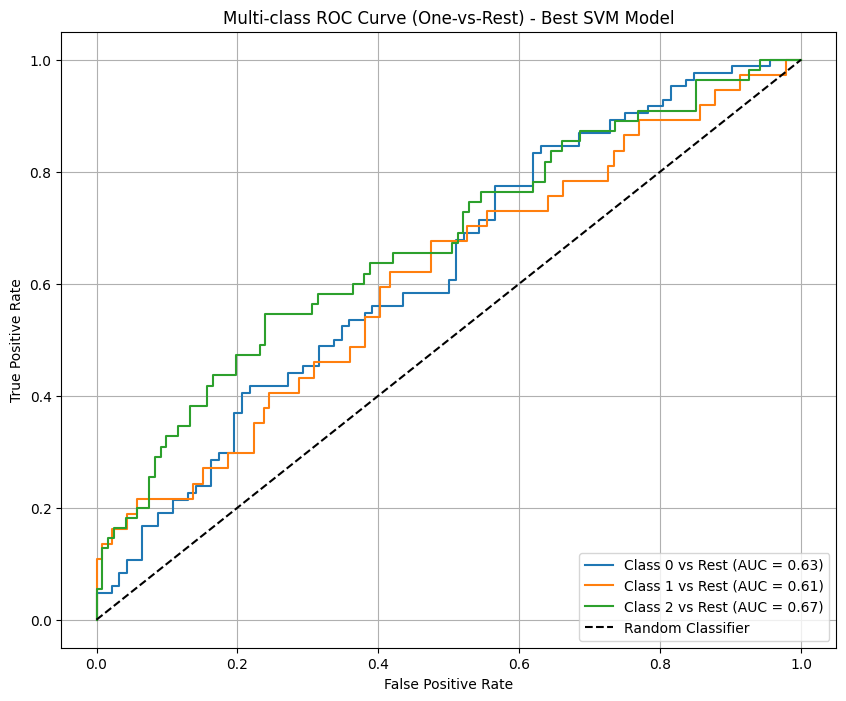


Overall Macro-averaged ROC AUC: 0.6361
Best CV macro F1-score: 0.4005 (± 0.0712)


In [80]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, roc_auc_score

# Assuming 'grid' from the last GridSearchCV run (for SVM) is available
best_svm_model = grid.best_estimator_

# Get class probabilities for the test set from the best SVM model
y_proba_svm = best_svm_model.predict_proba(X_test)

# Binarize y_test for OvR ROC curve plotting
lb = LabelBinarizer()
y_test_binarized = lb.fit_transform(y_test)
n_classes = y_test_binarized.shape[1]

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    # Calculate ROC curve for each class (One-vs-Rest)
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_proba_svm[:, i])
    auc_score = roc_auc_score(y_test_binarized[:, i], y_proba_svm[:, i])
    plt.plot(fpr, tpr, label=f'Class {lb.classes_[i]} vs Rest (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier') # Diagonal line for random classifier
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (One-vs-Rest) - Best SVM Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Calculate and print overall macro-average ROC AUC
overall_roc_auc_macro = roc_auc_score(y_test, y_proba_svm, multi_class="ovr", average="macro")
print(f"\nOverall Macro-averaged ROC AUC: {overall_roc_auc_macro:.4f}")

# Access the best score and its standard deviation from GridSearchCV results
best_index = grid.best_index_
mean_f1_macro = grid.cv_results_['mean_test_f1_macro'][best_index]
std_f1_macro = grid.cv_results_['std_test_f1_macro'][best_index]

print(f"Best CV macro F1-score: {mean_f1_macro:.4f} (± {std_f1_macro:.4f})")